<h1>Part 1: Building, cleaning and diagnostics (WU PWS v2 Schema)</h1>

**Inputs**
- Station CSV downloaded from WU/The Weather Company hourly endpoint using your `wu_pws_downloader_v2.py` (schema `v2`).

**Outputs**
- `train_table_v2_<station>.csv`: station + base merged, targets engineered, first 2 weeks removed
- `diagnostics_v2_<station>.json`: decisions + evidence for unresolved metadata (pressure type, precip source, gust alignment, time-lag)

<h2>1.1: Imports and display helpers </h2>

In [1]:
import os
import json
import time
import math
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

plt.rcParams["figure.figsize"] = (12, 5)

<h2>1.2: Configurations</h2>

In [21]:
STATION_ID = "ITRIPO33"

STATION_CSV_PATH = r"C:\Users\m\Desktop\mozen\Data Aquisition\V2\ITRIPO33_oct_feb.csv" 
OUTPUT_DIR = Path("eda_v2_outputs_part1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REMOVE_FIRST_N_DAYS = 18

LAG_TEST_RANGE = list(range(-3, 4))

BASE_API_HOST = "https://historical-forecast-api.open-meteo.com/v1/forecast"

BASE_MODELS_TRY = ["ecmwf_ifs025"]

BASE_TIMEZONE = "GMT"
CACHE_DIR = OUTPUT_DIR / "openmeteo_cache"
CACHE_DIR.mkdir(exist_ok=True)

FORCE_LAT = 32.881258
FORCE_LON = 13.160197

FORCE_ELEVATION_M = 10

QC_RANGES = {
    "temp_avg_c": (-30, 60),
    "humidity_avg_pct": (0, 100),
    "dewpoint_avg_c": (-40, 40),
    "windspeed_avg_kmh": (0, 200),
    "windgust_high_kmh": (0, 250),
    "pressure_avg_hpa": (850, 1100),  
    "uv_high": (0, 20),
    "solar_radiation_high_wm2": (0, 1500),
    "precip_rate_mmh": (0, 300),
    "precip_total_mm": (0, 5000),
}

<h2>1.3: Utility functions</h2>

In [4]:
def to_utc_datetime(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, utc=True, errors="coerce")

def ensure_hour_utc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "hour_utc" in df.columns:
        df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True, errors="coerce")
    elif "timestamp_utc" in df.columns:
        df["hour_utc"] = to_utc_datetime(df["timestamp_utc"]).dt.round("h")
    else:
        raise ValueError("Need hour_utc or timestamp_utc column.")
    return df

def circular_diff_deg(obs_deg: pd.Series, base_deg: pd.Series) -> pd.Series:
    obs = pd.to_numeric(obs_deg, errors="coerce")
    base = pd.to_numeric(base_deg, errors="coerce")
    return (obs - base + 180.0) % 360.0 - 180.0

def wind_to_uv(speed_kmh: pd.Series, dir_from_deg: pd.Series) -> Tuple[pd.Series, pd.Series]:
    spd = pd.to_numeric(speed_kmh, errors="coerce")
    d = pd.to_numeric(dir_from_deg, errors="coerce")
    theta = np.deg2rad(d % 360.0)
    u = -spd * np.sin(theta)
    v = -spd * np.cos(theta)
    return u, v

def safe_corr(a: pd.Series, b: pd.Series) -> float:
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    mask = a.notna() & b.notna()
    if mask.sum() < 50:
        return float("nan")
    return float(a[mask].corr(b[mask]))

def apply_range_qc(df: pd.DataFrame, ranges: Dict[str, Tuple[float, float]]) -> pd.DataFrame:
    df = df.copy()
    df["qc_any_out_of_range"] = 0

    for col, (lo, hi) in ranges.items():
        if col not in df.columns:
            continue
        x = pd.to_numeric(df[col], errors="coerce")
        out = (x < lo) | (x > hi)
        flag_col = f"qc_oor__{col}"
        df[flag_col] = out.astype(int)
        df["qc_any_out_of_range"] = np.maximum(df["qc_any_out_of_range"], df[flag_col])

    return df

def compute_best_lag_correlation(df: pd.DataFrame, station_col: str, base_col: str, lags: List[int]) -> Dict:
    res = {"station_col": station_col, "base_col": base_col, "corr_by_lag": {}, "best_lag": None, "best_corr": None}
    if station_col not in df.columns or base_col not in df.columns:
        return res

    s = pd.to_numeric(df[station_col], errors="coerce")
    b = pd.to_numeric(df[base_col], errors="coerce")

    best = (-999, None)
    for lag in lags:
        corr = safe_corr(s, b.shift(lag))
        res["corr_by_lag"][lag] = corr
        if not np.isnan(corr) and corr > best[0]:
            best = (corr, lag)

    res["best_corr"], res["best_lag"] = best[0], best[1]
    return res

def drop_all_missing_columns(df: pd.DataFrame) -> pd.DataFrame:
    miss = df.isna().mean()
    drop = miss[miss >= 0.999].index.tolist()
    if drop:
        print("Dropping 100% missing columns:", drop)
        df = df.drop(columns=drop)
    return df

<h2>1.4: Load WU v2 CSV</h2>

Station CSV shape: (3264, 44)


,hour_utc,n_raw_records,station_id,latitude,longitude,neighborhood,country,software_type,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_avg_hpa,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present
0,2025-10-11 23:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,NaN,NaN,NaN,-1.0,1760223571,0.0,0.0,0.0,59.0,61.0,59.0,27.0,27.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,19.0,18.0,27.0,27.0,27.0,28.0,28.0,28.0,NaN,1014.22,1013.55,0.00,0.0,0.0,2025-10-11 23:00:00+00:00,2025-10-11T23:00:00Z,10/12/2025 0:59,1
1,2025-10-12 00:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,NaN,NaN,NaN,-1.0,1760227171,0.0,0.0,0.0,60.0,61.0,60.0,27.0,27.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,19.0,18.0,27.0,27.0,27.0,28.0,28.0,28.0,NaN,1014.22,1013.55,0.00,0.0,0.0,2025-10-12 00:00:00+00:00,2025-10-12T00:00:00Z,10/12/2025 1:59,1
2,2025-10-12 01:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,NaN,NaN,NaN,-1.0,1760230771,0.0,0.0,0.0,60.0,62.0,60.0,27.0,27.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,19.0,18.0,27.0,27.0,27.0,28.0,28.0,28.0,NaN,1013.88,1013.55,-0.34,0.0,0.0,2025-10-12 01:00:00+00:00,2025-10-12T01:00:00Z,10/12/2025 2:59,1


Missing expected columns (not fatal): []
Duplicate hour_utc rows: 0


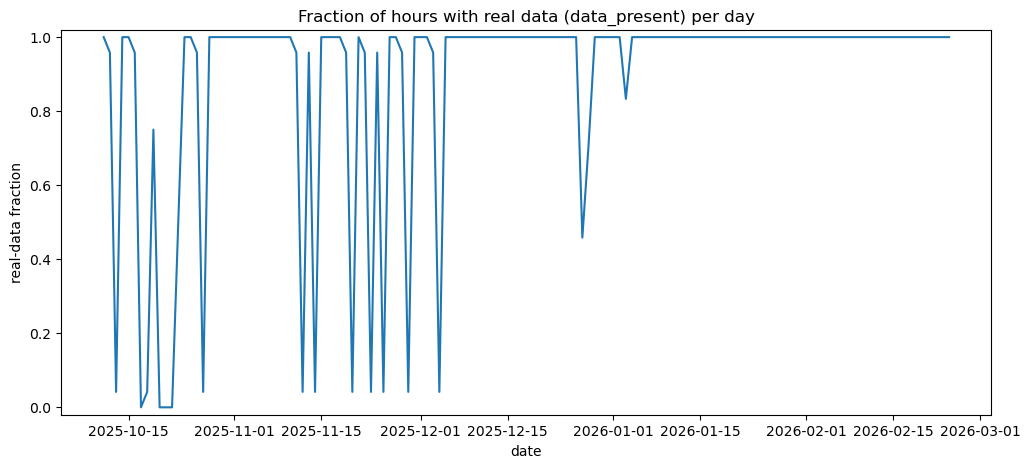

In [5]:
df_station = pd.read_csv(STATION_CSV_PATH)
df_station.columns = [c.strip() for c in df_station.columns]
df_station = ensure_hour_utc(df_station)

df_station = df_station.sort_values("hour_utc").reset_index(drop=True)

print("Station CSV shape:", df_station.shape)
display(df_station.head(3))

expected_cols = [
    "station_id", "timestamp_utc", "hour_utc", "latitude", "longitude",
    "temp_avg_c", "windspeed_avg_kmh", "winddir_avg_deg",
    "humidity_avg_pct", "dewpoint_avg_c",
    "pressure_avg_hpa", "pressure_max_hpa",
    "windgust_avg_kmh", "windgust_high_kmh",
    "precip_rate_mmh", "precip_total_mm",
    "uv_high", "solar_radiation_high_wm2",
    "data_present"
]
missing_expected = [c for c in expected_cols if c not in df_station.columns]
print("Missing expected columns (not fatal):", missing_expected)

dup_hours = df_station["hour_utc"].duplicated().sum()
print("Duplicate hour_utc rows:", dup_hours)

if "data_present" in df_station.columns:
    daily_present = df_station.set_index("hour_utc")["data_present"].resample("D").mean()
    plt.figure()
    plt.plot(daily_present.index, daily_present.values)
    plt.title("Fraction of hours with real data (data_present) per day")
    plt.ylim(-0.02, 1.02)
    plt.ylabel("real-data fraction")
    plt.xlabel("date")
    plt.show()

<h2>1.5: “timestamp within hour” diagnostic </h2>

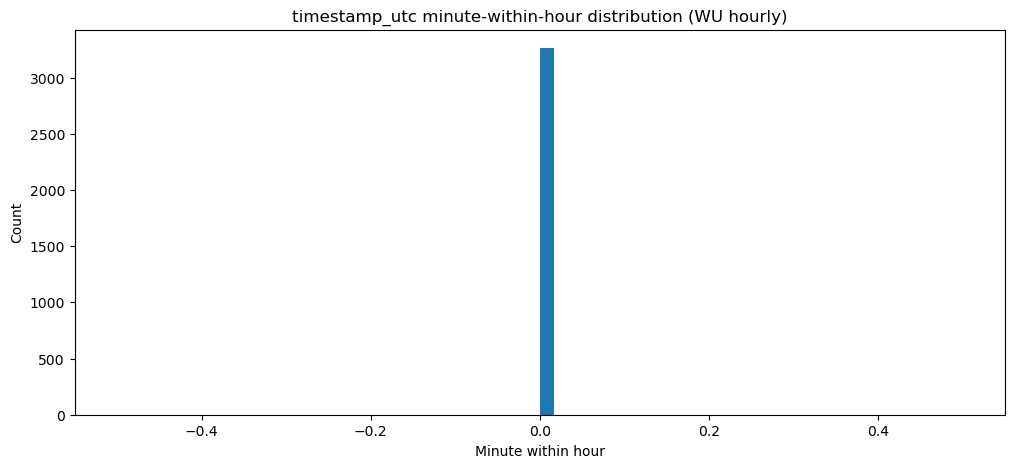

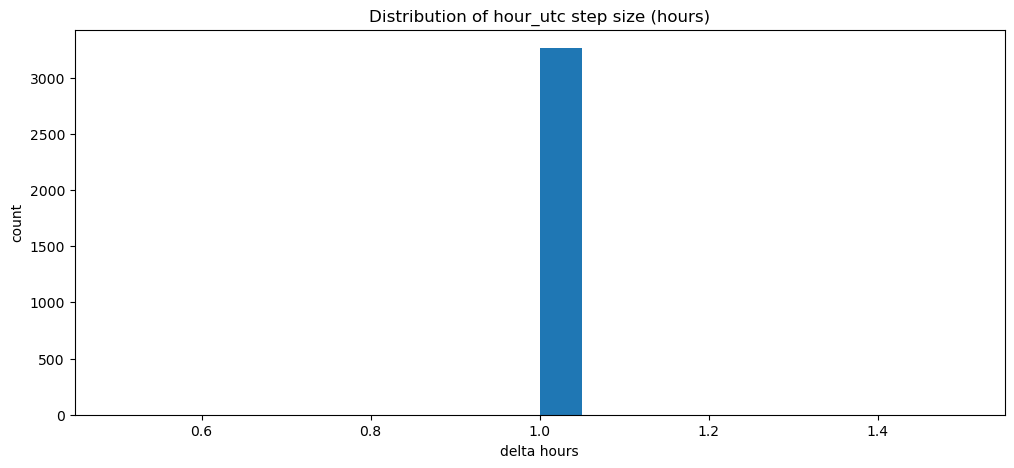

Most common deltas (hours):
hour_utc
1.0    3263
Name: count, dtype: int64


In [6]:
if "timestamp_utc" in df_station.columns:
    ts = to_utc_datetime(df_station["timestamp_utc"])
    mins = ts.dt.minute + ts.dt.second / 60.0

    plt.figure()
    plt.hist(mins.dropna(), bins=60)
    plt.title("timestamp_utc minute-within-hour distribution (WU hourly)")
    plt.xlabel("Minute within hour")
    plt.ylabel("Count")
    plt.show()

deltas = df_station["hour_utc"].diff().dt.total_seconds() / 3600.0
plt.figure()
plt.hist(deltas.dropna(), bins=20)
plt.title("Distribution of hour_utc step size (hours)")
plt.xlabel("delta hours")
plt.ylabel("count")
plt.show()

print("Most common deltas (hours):")
print(deltas.value_counts(dropna=True).head(10))

<h2>1.6: Apply broad QC range flags</h2>

QC range-flag columns: 10
Any out-of-range hours: 0


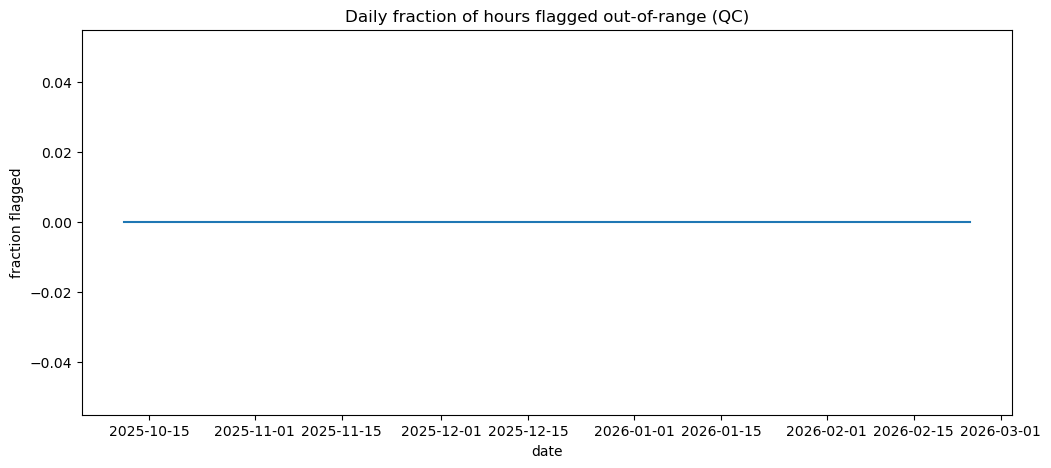

,hour_utc,n_raw_records,station_id,latitude,longitude,neighborhood,country,software_type,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_avg_hpa,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present,qc_any_out_of_range,qc_oor__temp_avg_c,qc_oor__humidity_avg_pct,qc_oor__dewpoint_avg_c,qc_oor__windspeed_avg_kmh,qc_oor__windgust_high_kmh,qc_oor__pressure_avg_hpa,qc_oor__uv_high,qc_oor__solar_radiation_high_wm2,qc_oor__precip_rate_mmh,qc_oor__precip_total_mm


In [7]:
df_station_qc = apply_range_qc(df_station, QC_RANGES)

qc_cols = [c for c in df_station_qc.columns if c.startswith("qc_oor__")]
print("QC range-flag columns:", len(qc_cols))
print("Any out-of-range hours:", int(df_station_qc["qc_any_out_of_range"].sum()))

qc_daily = df_station_qc.set_index("hour_utc")["qc_any_out_of_range"].resample("D").mean()

plt.figure()
plt.plot(qc_daily.index, qc_daily.values)
plt.title("Daily fraction of hours flagged out-of-range (QC)")
plt.ylabel("fraction flagged")
plt.xlabel("date")
plt.show()

display(df_station_qc[df_station_qc["qc_any_out_of_range"] == 1].head(10))

<h2>1.7: Precipitation inference:</h2>

{
  "rate_mm_equiv": {
    "name": "rate_mm_equiv",
    "nonzero_frac": 0.022058823529411766,
    "p50": 0.0,
    "p90": 0.0,
    "p99": 0.51,
    "max": 6.35
  },
  "total_inc_mm": {
    "name": "total_inc_mm",
    "nonzero_frac": 0.015625,
    "p50": 0.0,
    "p90": 0.0,
    "p99": 0.51,
    "max": 6.86
  },
  "corr_rate_vs_totalinc": 0.7867617206537152
}


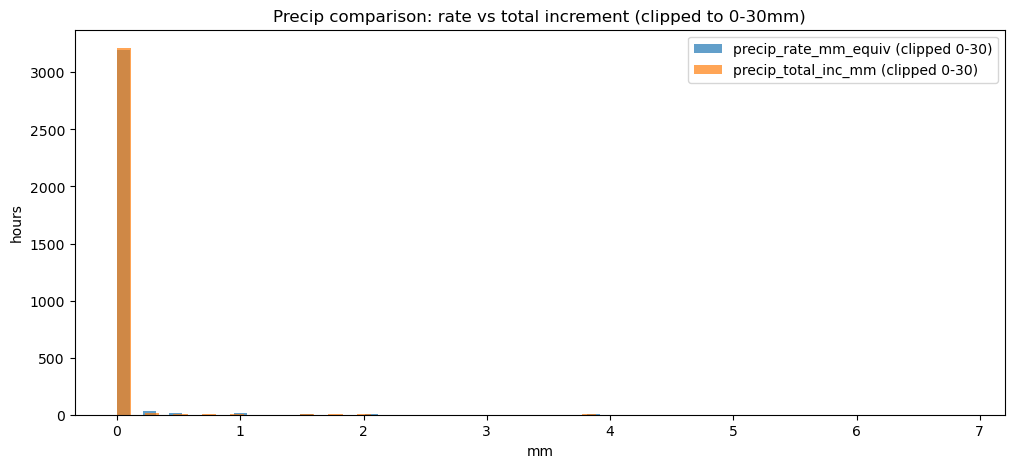

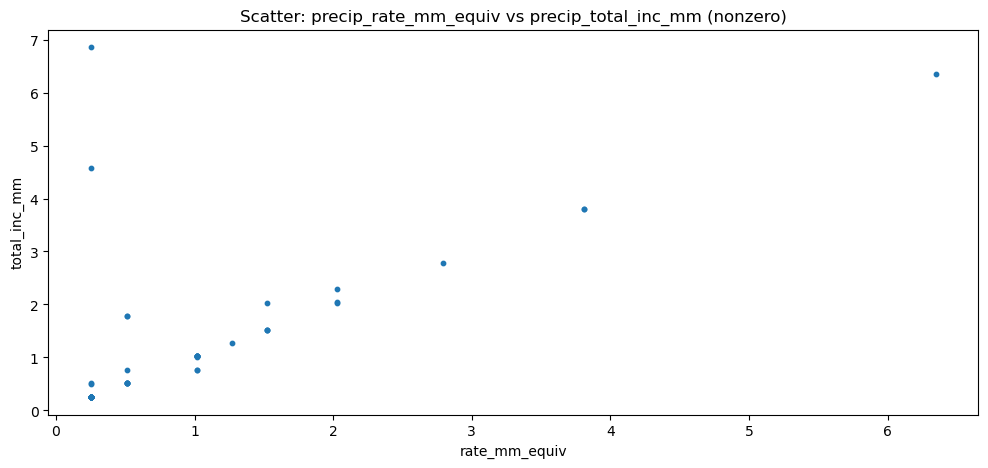

Chosen station_precip_mm source: precip_total_inc_mm


In [8]:
df = df_station_qc.copy().sort_values("hour_utc").reset_index(drop=True)

rate = pd.to_numeric(df.get("precip_rate_mmh"), errors="coerce")
tot = pd.to_numeric(df.get("precip_total_mm"), errors="coerce")

tot_diff = tot.diff()
tot_inc = np.where(tot_diff < 0, tot, tot_diff)  
tot_inc = pd.Series(tot_inc, index=df.index).clip(lower=0)

df["precip_total_inc_mm"] = tot_inc
df["precip_rate_mm_equiv"] = rate.clip(lower=0)  

def summarize_precip(name, s):
    s = pd.to_numeric(s, errors="coerce")
    return {
        "name": name,
        "nonzero_frac": float((s > 0).mean()),
        "p50": float(s.quantile(0.50)),
        "p90": float(s.quantile(0.90)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
    }

precip_summary = {
    "rate_mm_equiv": summarize_precip("rate_mm_equiv", df["precip_rate_mm_equiv"]),
    "total_inc_mm": summarize_precip("total_inc_mm", df["precip_total_inc_mm"]),
    "corr_rate_vs_totalinc": safe_corr(df["precip_rate_mm_equiv"], df["precip_total_inc_mm"]),
}

print(json.dumps(precip_summary, indent=2))

plt.figure()
plt.hist(df["precip_rate_mm_equiv"].fillna(0).clip(0, 30), bins=60, alpha=0.7, label="precip_rate_mm_equiv (clipped 0-30)")
plt.hist(df["precip_total_inc_mm"].fillna(0).clip(0, 30), bins=60, alpha=0.7, label="precip_total_inc_mm (clipped 0-30)")
plt.title("Precip comparison: rate vs total increment (clipped to 0-30mm)")
plt.xlabel("mm")
plt.ylabel("hours")
plt.legend()
plt.show()

mask = (df["precip_rate_mm_equiv"] > 0) & (df["precip_total_inc_mm"] > 0)
plt.figure()
plt.scatter(df.loc[mask, "precip_rate_mm_equiv"], df.loc[mask, "precip_total_inc_mm"], s=10)
plt.title("Scatter: precip_rate_mm_equiv vs precip_total_inc_mm (nonzero)")
plt.xlabel("rate_mm_equiv")
plt.ylabel("total_inc_mm")
plt.show()

corr = precip_summary["corr_rate_vs_totalinc"]
if not np.isnan(corr) and corr >= 0.6:
    df["station_precip_mm"] = df["precip_total_inc_mm"]
    precip_choice = "precip_total_inc_mm"
else:
    df["station_precip_mm"] = df["precip_rate_mm_equiv"]
    precip_choice = "precip_rate_mm_equiv"

print("Chosen station_precip_mm source:", precip_choice)
df["station_precip_choice"] = precip_choice

<h2>1.8: Open‑Meteo base forecast fetch</h2>

In [12]:
REQUEST_HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "pressure_msl",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
    "precipitation",
    "rain",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "sunshine_duration",
    "weather_code",
]

REQUEST_DAILY_VARS = ["sunrise", "sunset"]

BASE_RENAME = {
    "temperature_2m": "base_temp_c",
    "relative_humidity_2m": "base_humidity_pct",
    "dew_point_2m": "base_dewpoint_c",
    "pressure_msl": "base_pressure_msl_hpa",
    "surface_pressure": "base_surface_pressure_hpa",
    "wind_speed_10m": "base_windspeed_kmh",
    "wind_direction_10m": "base_winddir_deg",
    "wind_gusts_10m": "base_windgust_kmh",
    "precipitation": "base_precip_mm",
    "rain": "base_rain_mm",
    "cloud_cover": "base_cloud_pct",
    "cloud_cover_low": "base_cloud_low_pct",
    "cloud_cover_mid": "base_cloud_mid_pct",
    "cloud_cover_high": "base_cloud_high_pct",
    "shortwave_radiation": "base_shortwave_wm2",
    "direct_radiation": "base_direct_wm2",
    "diffuse_radiation": "base_diffuse_wm2",
    "sunshine_duration": "base_sunshine_sec",
    "weather_code": "base_weather_code",
}

def openmeteo_cache_key(lat, lon, start_date, end_date, model, hourly_vars, daily_vars):
    hv = ",".join(hourly_vars)
    dv = ",".join(daily_vars)
    return f"om_{lat:.5f}_{lon:.5f}_{start_date}_{end_date}_model{model}_H{hash(hv)}_D{hash(dv)}.json"

def fetch_openmeteo_json(lat, lon, start_date, end_date, model: Optional[str], hourly_vars, daily_vars, elevation_m=None):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_vars) if hourly_vars else None,
        "daily": ",".join(daily_vars) if daily_vars else None,
        "timezone": BASE_TIMEZONE,
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "precipitation_unit": "mm",
    }
    if model:
        params["models"] = model
    if elevation_m is not None:
        params["elevation"] = elevation_m

    params = {k: v for k, v in params.items() if v is not None}

    r = requests.get(BASE_API_HOST, params=params, timeout=45)
    data = r.json()
    if isinstance(data, dict) and data.get("error"):
        raise RuntimeError(data.get("reason", "Open-Meteo error"))
    r.raise_for_status()
    return data

def fetch_openmeteo_with_var_fallback(lat, lon, start_date, end_date, model_try_list, hourly_vars, daily_vars, elevation_m=None, max_passes=5):
    vars_current = list(hourly_vars)

    last_err = None
    for model in model_try_list + [None]:
        vars_current = list(hourly_vars)  
        for _ in range(max_passes):
            try:
                ck = openmeteo_cache_key(lat, lon, start_date, end_date, model or "auto", vars_current, daily_vars)
                cache_path = CACHE_DIR / ck
                if cache_path.exists():
                    data = json.loads(cache_path.read_text())
                else:
                    data = fetch_openmeteo_json(
                        lat, lon, start_date, end_date,
                        model=model,
                        hourly_vars=vars_current,
                        daily_vars=daily_vars,
                        elevation_m=elevation_m
                    )
                    cache_path.write_text(json.dumps(data))
                return data, model, vars_current
            except Exception as e:
                last_err = e
                msg = str(e)

                if "not supported" in msg.lower():
                    parts = msg.split(":")
                    if len(parts) >= 2:
                        bad = parts[-1]
                        bad_vars = [v.strip().strip(".") for v in bad.split(",")]
                        bad_vars = [v for v in bad_vars if v in vars_current]
                        if bad_vars:
                            print("Open-Meteo unsupported vars removed:", bad_vars)
                            vars_current = [v for v in vars_current if v not in bad_vars]
                            continue
                break

    raise RuntimeError(f"Open-Meteo fetch failed. Last error: {last_err}")

def openmeteo_to_frames(data: dict) -> Tuple[pd.DataFrame, pd.DataFrame]:
    hourly = data.get("hourly", {})
    if "time" not in hourly:
        raise RuntimeError("Open-Meteo response missing hourly.time")

    dfh = pd.DataFrame({"hour_utc": pd.to_datetime(hourly["time"], utc=True)})
    for k, arr in hourly.items():
        if k == "time":
            continue
        dfh[k] = arr

    for k, newk in BASE_RENAME.items():
        if k in dfh.columns:
            dfh = dfh.rename(columns={k: newk})

    dfd = pd.DataFrame()
    daily = data.get("daily", {})
    if daily and "time" in daily:
        dfd = pd.DataFrame({"date_utc": pd.to_datetime(daily["time"], utc=True).date})
        if "sunrise" in daily:
            dfd["sunrise_utc"] = pd.to_datetime(daily["sunrise"], utc=True)
        if "sunset" in daily:
            dfd["sunset_utc"] = pd.to_datetime(daily["sunset"], utc=True)
        if "sunrise_utc" in dfd.columns and "sunset_utc" in dfd.columns:
            dfd["daylight_duration_sec"] = (dfd["sunset_utc"] - dfd["sunrise_utc"]).dt.total_seconds()

    return dfh, dfd

<h2>1.9: Merge</h2>

In [13]:
lat = FORCE_LAT if FORCE_LAT is not None else float(df["latitude"].dropna().iloc[0])
lon = FORCE_LON if FORCE_LON is not None else float(df["longitude"].dropna().iloc[0])
elev = FORCE_ELEVATION_M

start_date = (df["hour_utc"].min() - pd.Timedelta(days=1)).date().isoformat()
end_date = (df["hour_utc"].max() + pd.Timedelta(days=1)).date().isoformat()

print("Fetching Open-Meteo baseline for:")
print(" lat/lon:", lat, lon, " elevation_m:", elev)
print(" start_date:", start_date, " end_date:", end_date)

data, used_model, used_hourly_vars = fetch_openmeteo_with_var_fallback(
    lat=lat, lon=lon,
    start_date=start_date, end_date=end_date,
    model_try_list=BASE_MODELS_TRY,
    hourly_vars=REQUEST_HOURLY_VARS,
    daily_vars=REQUEST_DAILY_VARS,
    elevation_m=elev
)

print("Open-Meteo model used:", used_model or "auto")
print("Hourly vars used:", used_hourly_vars)

df_base_h, df_base_d = openmeteo_to_frames(data)

print("Base hourly shape:", df_base_h.shape)
display(df_base_h.head(3))

dfm = df.merge(df_base_h, on="hour_utc", how="left")

if len(df_base_d) > 0:
    dfm["date_utc"] = dfm["hour_utc"].dt.date
    dfm = dfm.merge(df_base_d, on="date_utc", how="left")

dfm = drop_all_missing_columns(dfm)

print("Merged station+base shape:", dfm.shape)
display(dfm.head(3))

Fetching Open-Meteo baseline for:
 lat/lon: 32.881258 13.160197  elevation_m: 10
 start_date: 2025-10-10  end_date: 2026-02-25
Open-Meteo model used: ecmwf_ifs025
Hourly vars used: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'pressure_msl', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'precipitation', 'rain', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'sunshine_duration', 'weather_code']
Base hourly shape: (3336, 20)


,hour_utc,base_temp_c,base_humidity_pct,base_dewpoint_c,base_pressure_msl_hpa,base_surface_pressure_hpa,base_windspeed_kmh,base_winddir_deg,base_windgust_kmh,base_precip_mm,base_rain_mm,base_cloud_pct,base_cloud_low_pct,base_cloud_mid_pct,base_cloud_high_pct,base_shortwave_wm2,base_direct_wm2,base_diffuse_wm2,base_sunshine_sec,base_weather_code
0,2025-10-10 00:00:00+00:00,20.2,64,13.2,1021.1,1019.9,7.9,114,19.1,0.0,0.0,10,0,0,35,0.0,0.0,0.0,0.0,0
1,2025-10-10 01:00:00+00:00,20.0,59,11.8,1020.8,1019.6,7.6,135,18.7,0.0,0.0,15,0,10,31,0.0,0.0,0.0,0.0,0
2,2025-10-10 02:00:00+00:00,20.0,52,9.9,1020.5,1019.3,9.0,157,18.0,0.0,0.0,31,0,38,30,0.0,0.0,0.0,0.0,1


Dropping 100% missing columns: ['neighborhood', 'country', 'software_type', 'pressure_avg_hpa']
Merged station+base shape: (3264, 78)


,hour_utc,n_raw_records,station_id,latitude,longitude,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present,qc_any_out_of_range,qc_oor__temp_avg_c,qc_oor__humidity_avg_pct,qc_oor__dewpoint_avg_c,qc_oor__windspeed_avg_kmh,qc_oor__windgust_high_kmh,qc_oor__pressure_avg_hpa,qc_oor__uv_high,qc_oor__solar_radiation_high_wm2,qc_oor__precip_rate_mmh,qc_oor__precip_total_mm,precip_total_inc_mm,precip_rate_mm_equiv,station_precip_mm,station_precip_choice,base_temp_c,base_humidity_pct,base_dewpoint_c,base_pressure_msl_hpa,base_surface_pressure_hpa,base_windspeed_kmh,base_winddir_deg,base_windgust_kmh,base_precip_mm,base_rain_mm,base_cloud_pct,base_cloud_low_pct,base_cloud_mid_pct,base_cloud_high_pct,base_shortwave_wm2,base_direct_wm2,base_diffuse_wm2,base_sunshine_sec,base_weather_code,date_utc,sunrise_utc,sunset_utc,daylight_duration_sec
0,2025-10-11 23:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1760223571,0.0,0.0,0.0,59.0,61.0,59.0,27.0,27.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,19.0,18.0,27.0,27.0,27.0,28.0,28.0,28.0,1014.22,1013.55,0.00,0.0,0.0,2025-10-11 23:00:00+00:00,2025-10-11T23:00:00Z,10/12/2025 0:59,1,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,precip_total_inc_mm,20.2,77,16.0,1022.7,1021.5,6.2,126,12.6,0.0,0.0,23,0,0,83,0.0,0.0,0.0,0.0,1,2025-10-11,2025-10-11 05:08:00+00:00,2025-10-11 16:38:00+00:00,41400.0
1,2025-10-12 00:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1760227171,0.0,0.0,0.0,60.0,61.0,60.0,27.0,27.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,19.0,18.0,27.0,27.0,27.0,28.0,28.0,28.0,1014.22,1013.55,0.00,0.0,0.0,2025-10-12 00:00:00+00:00,2025-10-12T00:00:00Z,10/12/2025 1:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,19.5,79,15.8,1022.6,1021.4,5.9,133,11.2,0.0,0.0,33,0,6,100,0.0,0.0,0.0,0.0,1,2025-10-12,2025-10-12 05:09:00+00:00,2025-10-12 16:37:00+00:00,41280.0
2,2025-10-12 01:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1760230771,0.0,0.0,0.0,60.0,62.0,60.0,27.0,27.0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,19.0,18.0,27.0,27.0,27.0,28.0,28.0,28.0,1013.88,1013.55,-0.34,0.0,0.0,2025-10-12 01:00:00+00:00,2025-10-12T01:00:00Z,10/12/2025 2:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,18.9,81,15.6,1022.3,1021.1,5.4,132,10.1,0.0,0.0,40,0,30,77,0.0,0.0,0.0,0.0,1,2025-10-12,2025-10-12 05:09:00+00:00,2025-10-12 16:37:00+00:00,41280.0


<h2>1.10: Build Targets and wind/solar </h2>

In [15]:
dfm = dfm.sort_values("hour_utc").reset_index(drop=True)

dfm["station_temp_c"] = pd.to_numeric(dfm.get("temp_avg_c"), errors="coerce")
dfm["station_rh_pct"] = pd.to_numeric(dfm.get("humidity_avg_pct"), errors="coerce")
dfm["station_dewpoint_c"] = pd.to_numeric(dfm.get("dewpoint_avg_c"), errors="coerce")
dfm["station_windspeed_kmh"] = pd.to_numeric(dfm.get("windspeed_avg_kmh"), errors="coerce")
dfm["station_winddir_deg"] = pd.to_numeric(dfm.get("winddir_avg_deg"), errors="coerce")

pressure_avg = pd.to_numeric(
    dfm.get("pressure_avg_hpa", pd.Series(index=dfm.index, dtype="float64")),
    errors="coerce"
)
pressure_max = pd.to_numeric(
    dfm.get("pressure_max_hpa", pd.Series(index=dfm.index, dtype="float64")),
    errors="coerce"
)
dfm["station_pressure_hpa"] = pressure_avg.where(pressure_avg.notna(), pressure_max)

dfm["station_gust_avg_kmh"] = pd.to_numeric(dfm.get("windgust_avg_kmh"), errors="coerce")
dfm["station_gust_high_kmh"] = pd.to_numeric(dfm.get("windgust_high_kmh"), errors="coerce")

dfm["station_precip_mm"] = pd.to_numeric(dfm.get("station_precip_mm"), errors="coerce")

dfm["uv_target"] = pd.to_numeric(dfm.get("uv_high"), errors="coerce")

dfm["temp_error_c"] = dfm["station_temp_c"] - pd.to_numeric(dfm.get("base_temp_c"), errors="coerce")
dfm["rh_error_pct"] = dfm["station_rh_pct"] - pd.to_numeric(dfm.get("base_humidity_pct"), errors="coerce")
dfm["dewpoint_error_c"] = dfm["station_dewpoint_c"] - pd.to_numeric(dfm.get("base_dewpoint_c"), errors="coerce")
dfm["wind_error_kmh"] = dfm["station_windspeed_kmh"] - pd.to_numeric(dfm.get("base_windspeed_kmh"), errors="coerce")
dfm["winddir_error_deg"] = circular_diff_deg(dfm["station_winddir_deg"], dfm.get("base_winddir_deg"))

base_rain = "base_rain_mm" if "base_rain_mm" in dfm.columns else ("base_precip_mm" if "base_precip_mm" in dfm.columns else None)
if base_rain:
    dfm["rain_error_mm"] = dfm["station_precip_mm"] - pd.to_numeric(dfm[base_rain], errors="coerce")
else:
    dfm["rain_error_mm"] = np.nan

dfm["pressure_error_vs_surface_hpa"] = dfm["station_pressure_hpa"] - pd.to_numeric(dfm.get("base_surface_pressure_hpa"), errors="coerce")
dfm["pressure_error_vs_msl_hpa"] = dfm["station_pressure_hpa"] - pd.to_numeric(dfm.get("base_pressure_msl_hpa"), errors="coerce")

dfm["station_gust_high_3hmax_kmh"] = dfm["station_gust_high_kmh"].rolling(3, min_periods=1).max()
dfm["gust_error_high_hourly_kmh"] = dfm["station_gust_high_kmh"] - pd.to_numeric(dfm.get("base_windgust_kmh"), errors="coerce")
dfm["gust_error_high_3hmax_kmh"] = dfm["station_gust_high_3hmax_kmh"] - pd.to_numeric(dfm.get("base_windgust_kmh"), errors="coerce")
dfm["gust_error_avg_hourly_kmh"] = dfm["station_gust_avg_kmh"] - pd.to_numeric(dfm.get("base_windgust_kmh"), errors="coerce")

dfm["station_u_kmh"], dfm["station_v_kmh"] = wind_to_uv(dfm["station_windspeed_kmh"], dfm["station_winddir_deg"])
dfm["base_u_kmh"], dfm["base_v_kmh"] = wind_to_uv(pd.to_numeric(dfm.get("base_windspeed_kmh"), errors="coerce"),
                                                  pd.to_numeric(dfm.get("base_winddir_deg"), errors="coerce"))
dfm["wind_u_error_kmh"] = dfm["station_u_kmh"] - dfm["base_u_kmh"]
dfm["wind_v_error_kmh"] = dfm["station_v_kmh"] - dfm["base_v_kmh"]

if "sunrise_utc" in dfm.columns and "sunset_utc" in dfm.columns:
    sunrise = pd.to_datetime(dfm["sunrise_utc"], utc=True, errors="coerce")
    sunset  = pd.to_datetime(dfm["sunset_utc"], utc=True, errors="coerce")
    dfm["is_day"] = ((dfm["hour_utc"] >= sunrise) & (dfm["hour_utc"] < sunset)).astype(float)
else:
    dfm["is_day"] = np.nan

display(dfm[[
    "hour_utc",
    "station_temp_c","base_temp_c","temp_error_c",
    "station_windspeed_kmh","base_windspeed_kmh","wind_error_kmh",
    "station_winddir_deg","base_winddir_deg","winddir_error_deg",
    "station_pressure_hpa","base_surface_pressure_hpa","base_pressure_msl_hpa",
    "pressure_error_vs_surface_hpa","pressure_error_vs_msl_hpa",
    "station_precip_mm", base_rain if base_rain else "station_precip_mm", "rain_error_mm",
    "uv_target"
]].head(8))

,hour_utc,station_temp_c,base_temp_c,temp_error_c,station_windspeed_kmh,base_windspeed_kmh,wind_error_kmh,station_winddir_deg,base_winddir_deg,winddir_error_deg,station_pressure_hpa,base_surface_pressure_hpa,base_pressure_msl_hpa,pressure_error_vs_surface_hpa,pressure_error_vs_msl_hpa,station_precip_mm,base_rain_mm,rain_error_mm,uv_target
0,2025-10-11 23:00:00+00:00,27.0,20.2,6.8,0.0,6.2,-6.2,0.0,126,-126.0,1014.22,1021.5,1022.7,-7.28,-8.48,NaN,0.0,NaN,0.0
1,2025-10-12 00:00:00+00:00,27.0,19.5,7.5,0.0,5.9,-5.9,0.0,133,-133.0,1014.22,1021.4,1022.6,-7.18,-8.38,0.0,0.0,0.0,0.0
2,2025-10-12 01:00:00+00:00,27.0,18.9,8.1,0.0,5.4,-5.4,0.0,132,-132.0,1013.88,1021.1,1022.3,-7.22,-8.42,0.0,0.0,0.0,0.0
3,2025-10-12 02:00:00+00:00,27.0,18.4,8.6,0.0,5.1,-5.1,0.0,129,-129.0,1013.55,1020.6,1021.8,-7.05,-8.25,0.0,0.0,0.0,0.0
4,2025-10-12 03:00:00+00:00,27.0,18.2,8.8,0.0,4.9,-4.9,0.0,126,-126.0,1013.21,1020.4,1021.6,-7.19,-8.39,0.0,0.0,0.0,0.0
5,2025-10-12 04:00:00+00:00,26.0,18.1,7.9,0.0,5.4,-5.4,0.0,127,-127.0,1013.21,1020.5,1021.7,-7.29,-8.49,0.0,0.0,0.0,0.0
6,2025-10-12 05:00:00+00:00,26.0,18.3,7.7,0.0,6.2,-6.2,0.0,126,-126.0,1013.21,1020.8,1022.0,-7.59,-8.79,0.0,0.0,0.0,0.0
7,2025-10-12 06:00:00+00:00,26.0,19.1,6.9,0.0,7.0,-7.0,0.0,125,-125.0,1013.55,1021.1,1022.3,-7.55,-8.75,0.0,0.0,0.0,0.0


<h2>1.11: diagnose time alignment </h2>

Lag diagnosis (temp): {'station_col': 'station_temp_c', 'base_col': 'base_temp_c', 'corr_by_lag': {-3: 0.7165848061498211, -2: 0.7849752364873445, -1: 0.843971674548224, 0: 0.8862610564484977, 1: 0.9047785669104355, 2: 0.8981990822672719, 3: 0.8693823576543486}, 'best_lag': 1, 'best_corr': 0.9047785669104355}
Lag diagnosis (wind): {'station_col': 'station_windspeed_kmh', 'base_col': 'base_windspeed_kmh', 'corr_by_lag': {-3: 0.6734506050773453, -2: 0.7130866503197121, -1: 0.7394188694717143, 0: 0.7468504774592367, 1: 0.7324537921218398, 2: 0.7011771512145475, 3: 0.6598988439875201}, 'best_lag': 0, 'best_corr': 0.7468504774592367}


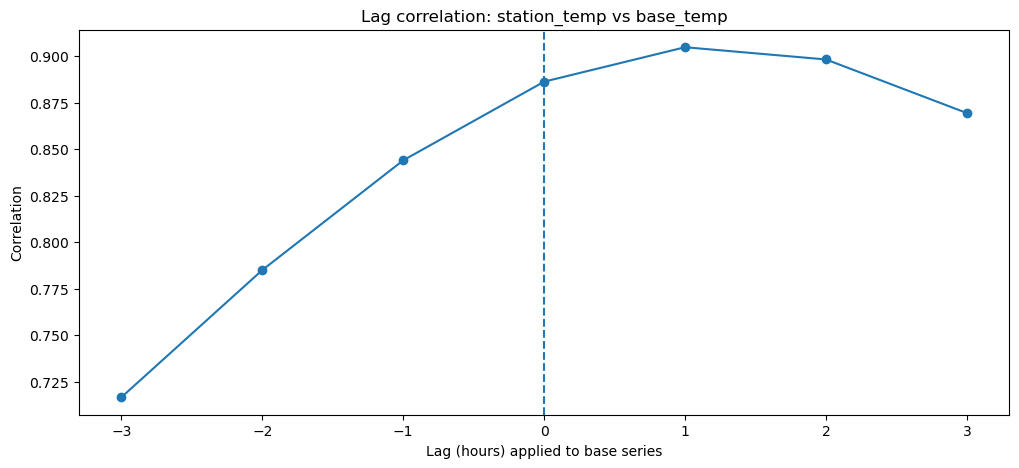

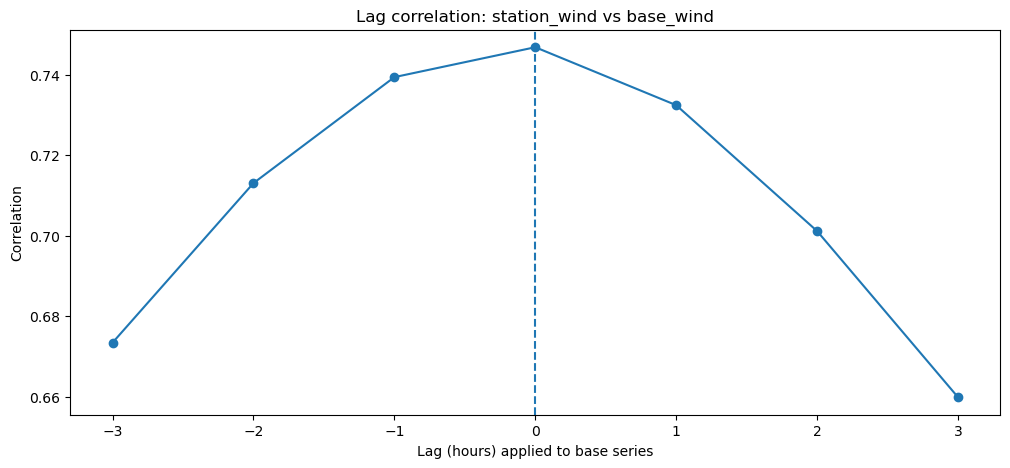

In [16]:
diagnostics = {}

df_real = dfm.copy()
if "data_present" in df_real.columns:
    df_real = df_real[df_real["data_present"] == 1].copy()

lag_temp = compute_best_lag_correlation(df_real, "station_temp_c", "base_temp_c", LAG_TEST_RANGE)
lag_wind = compute_best_lag_correlation(df_real, "station_windspeed_kmh", "base_windspeed_kmh", LAG_TEST_RANGE)

diagnostics["lag_temp"] = lag_temp
diagnostics["lag_wind"] = lag_wind

print("Lag diagnosis (temp):", lag_temp)
print("Lag diagnosis (wind):", lag_wind)

def plot_lag(res, title):
    lags = sorted(res["corr_by_lag"].keys())
    vals = [res["corr_by_lag"][l] for l in lags]
    plt.figure()
    plt.plot(lags, vals, marker="o")
    plt.title(title)
    plt.xlabel("Lag (hours) applied to base series")
    plt.ylabel("Correlation")
    plt.axvline(0, linestyle="--")
    plt.show()

plot_lag(lag_temp, "Lag correlation: station_temp vs base_temp")
plot_lag(lag_wind, "Lag correlation: station_wind vs base_wind")

note: Open meteo is most likely getting instantaneous data while the station is doing an hourly average and the hourly average of 10 might be 10-10:59 which is why looking ahead made it better so that might help out with the "average" feilds by shifting them back one but still need to double check

<h2>1.12: diagnose pressure type </h2>

{
  "n": 2779,
  "mae_vs_surface": 6.18866858582224,
  "mae_vs_msl": 6.782803166606693,
  "corr_vs_surface": 0.5998016630504075,
  "corr_vs_msl": 0.5998309472724653,
  "mean_station_minus_surface": -3.6279273119827304,
  "mean_station_minus_msl": -4.824940626124508,
  "likely_station_pressure_type": "station_surface (closer to base surface)"
}


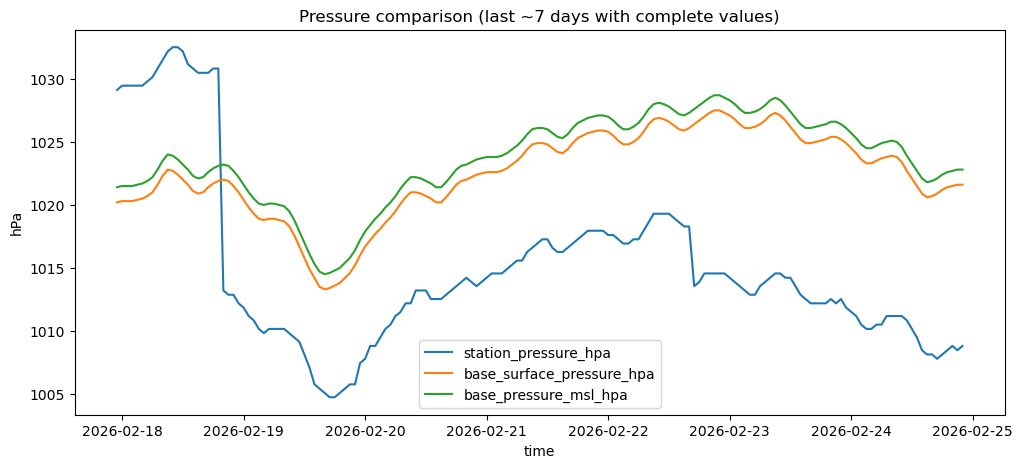

In [17]:
s = pd.to_numeric(df_real["station_pressure_hpa"], errors="coerce")
surf = pd.to_numeric(df_real.get("base_surface_pressure_hpa"), errors="coerce")
msl  = pd.to_numeric(df_real.get("base_pressure_msl_hpa"), errors="coerce")

pressure_diag = {
    "n": int(s.notna().sum()),
    "mae_vs_surface": float((s - surf).abs().mean()) if surf is not None else None,
    "mae_vs_msl": float((s - msl).abs().mean()) if msl is not None else None,
    "corr_vs_surface": safe_corr(s, surf),
    "corr_vs_msl": safe_corr(s, msl),
    "mean_station_minus_surface": float((s - surf).mean()) if surf is not None else None,
    "mean_station_minus_msl": float((s - msl).mean()) if msl is not None else None,
}

if pressure_diag["mae_vs_surface"] is not None and pressure_diag["mae_vs_msl"] is not None:
    if pressure_diag["mae_vs_msl"] + 0.5 < pressure_diag["mae_vs_surface"]:
        pressure_diag["likely_station_pressure_type"] = "sea_level_relative (closer to base MSL)"
        pressure_choice = "msl"
    elif pressure_diag["mae_vs_surface"] + 0.5 < pressure_diag["mae_vs_msl"]:
        pressure_diag["likely_station_pressure_type"] = "station_surface (closer to base surface)"
        pressure_choice = "surface"
    else:
        pressure_diag["likely_station_pressure_type"] = "ambiguous_or_mixed"
        pressure_choice = "ambiguous"
else:
    pressure_choice = "unknown"

diagnostics["pressure_diagnosis"] = pressure_diag
diagnostics["pressure_choice"] = pressure_choice

print(json.dumps(pressure_diag, indent=2))

sample = df_real[["hour_utc","station_pressure_hpa","base_surface_pressure_hpa","base_pressure_msl_hpa"]].dropna().tail(7*24)

plt.figure()
plt.plot(sample["hour_utc"], sample["station_pressure_hpa"], label="station_pressure_hpa")
if "base_surface_pressure_hpa" in sample.columns:
    plt.plot(sample["hour_utc"], sample["base_surface_pressure_hpa"], label="base_surface_pressure_hpa")
if "base_pressure_msl_hpa" in sample.columns:
    plt.plot(sample["hour_utc"], sample["base_pressure_msl_hpa"], label="base_pressure_msl_hpa")
plt.title("Pressure comparison (last ~7 days with complete values)")
plt.xlabel("time")
plt.ylabel("hPa")
plt.legend()
plt.show()

note: since the station pressure has a constant bias it seems that the sensor might be broken and a second station should be tested in order to check if this is a consistent issue with all the machinary or just this one stations.

<h2>1.13: diagnose gust </h2>

Gust diagnosis (sorted by MAE):
[
  {
    "name": "station_gust_avg_kmh",
    "n": 2886,
    "mae": 9.022487872487874,
    "bias": -7.654989604989605,
    "corr": 0.7418444962024365
  },
  {
    "name": "station_gust_high_kmh",
    "n": 2886,
    "mae": 9.043069993069993,
    "bias": 2.953465003465004,
    "corr": 0.7384710564067084
  },
  {
    "name": "station_gust_high_3hmax_kmh",
    "n": 2886,
    "mae": 10.887006237006236,
    "bias": 6.649930699930699,
    "corr": 0.7363613421350304
  }
]
Chosen gust alignment: station_gust_avg_kmh


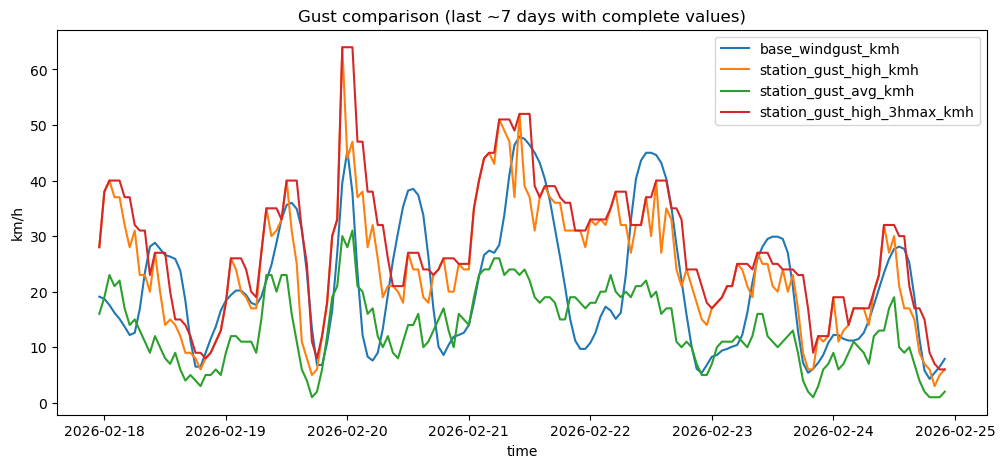

In [19]:
base_gust = pd.to_numeric(df_real.get("base_windgust_kmh"), errors="coerce")

def gust_stats(name, s):
    s = pd.to_numeric(s, errors="coerce")
    mask = s.notna() & base_gust.notna()
    if mask.sum() < 100:
        return {"name": name, "n": int(mask.sum()), "mae": None, "bias": None, "corr": None}
    return {
        "name": name,
        "n": int(mask.sum()),
        "mae": float((s[mask] - base_gust[mask]).abs().mean()),
        "bias": float((s[mask] - base_gust[mask]).mean()),
        "corr": float(s[mask].corr(base_gust[mask])),
    }

gust_diag = [
    gust_stats("station_gust_avg_kmh", df_real.get("station_gust_avg_kmh")),
    gust_stats("station_gust_high_kmh", df_real.get("station_gust_high_kmh")),
    gust_stats("station_gust_high_3hmax_kmh", df_real.get("station_gust_high_3hmax_kmh")),
]

gust_diag_sorted = sorted([g for g in gust_diag if g["mae"] is not None], key=lambda x: x["mae"])
diagnostics["gust_diagnosis"] = gust_diag_sorted

if gust_diag_sorted:
    best = gust_diag_sorted[0]["name"]
else:
    best = "unknown"

diagnostics["gust_choice"] = best

print("Gust diagnosis (sorted by MAE):")
print(json.dumps(gust_diag_sorted, indent=2))
print("Chosen gust alignment:", best)

sample = df_real[["hour_utc","base_windgust_kmh","station_gust_avg_kmh","station_gust_high_kmh","station_gust_high_3hmax_kmh"]].dropna().tail(7*24)

plt.figure()
plt.plot(sample["hour_utc"], sample["base_windgust_kmh"], label="base_windgust_kmh")
plt.plot(sample["hour_utc"], sample["station_gust_high_kmh"], label="station_gust_high_kmh")
plt.plot(sample["hour_utc"], sample["station_gust_avg_kmh"], label="station_gust_avg_kmh")
plt.plot(sample["hour_utc"], sample["station_gust_high_3hmax_kmh"], label="station_gust_high_3hmax_kmh")
plt.title("Gust comparison (last ~7 days with complete values)")
plt.xlabel("time")
plt.ylabel("km/h")
plt.legend()
plt.show()

note: same issue as pressure, we will check again with a second place.

<h2>1.14: first bad days mask test</h2>

First real hour: 2025-10-11 23:00:00+00:00
Cutoff (remove first N days): 2025-10-29 23:00:00+00:00
Before: (3264, 106) After: (2832, 106)


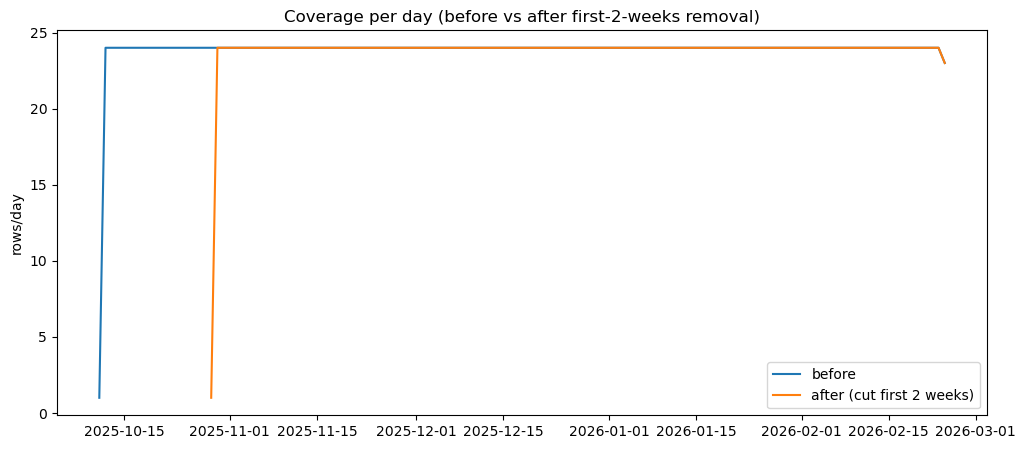

,mean_before,mean_after,std_before,std_after
winddir_error_deg,-7.140679,-8.018182,49.365151,40.030138
pressure_error_vs_msl_hpa,-4.824941,-4.684898,5.566075,5.661536
pressure_error_vs_surface_hpa,-3.627927,-3.487208,5.564717,5.659717
rh_error_pct,-0.356895,-0.546970,12.847545,12.223822
rain_error_mm,0.002274,0.007194,0.273070,0.262921
temp_error_c,0.836764,0.748939,2.494679,2.218408
dewpoint_error_c,1.643035,1.461402,2.653728,2.469436
wind_error_kmh,0.854782,1.612652,6.024456,5.612609
gust_error_high_hourly_kmh,2.953465,4.706326,11.745815,10.269306
gust_error_high_3hmax_kmh,6.602334,8.704250,12.810171,10.887844


In [22]:
df_clean = dfm.copy().sort_values("hour_utc").reset_index(drop=True)

if "data_present" in df_clean.columns:
    first_real = df_clean.loc[df_clean["data_present"] == 1, "hour_utc"].min()
    if pd.isna(first_real):
        first_real = df_clean["hour_utc"].min()
else:
    first_real = df_clean["hour_utc"].min()

cutoff = first_real + pd.Timedelta(days=REMOVE_FIRST_N_DAYS)
print("First real hour:", first_real)
print("Cutoff (remove first N days):", cutoff)

before_shape = df_clean.shape
df_clean = df_clean[df_clean["hour_utc"] >= cutoff].copy().reset_index(drop=True)
after_shape = df_clean.shape
print("Before:", before_shape, "After:", after_shape)

before_counts = dfm.set_index("hour_utc").resample("D").size()
after_counts  = df_clean.set_index("hour_utc").resample("D").size()

plt.figure()
plt.plot(before_counts.index, before_counts.values, label="before")
plt.plot(after_counts.index, after_counts.values, label="after (cut first 2 weeks)")
plt.title("Coverage per day (before vs after first-2-weeks removal)")
plt.ylabel("rows/day")
plt.legend()
plt.show()

targets = ["temp_error_c","wind_error_kmh","rh_error_pct","dewpoint_error_c","pressure_error_vs_surface_hpa","pressure_error_vs_msl_hpa","rain_error_mm","gust_error_high_hourly_kmh","gust_error_high_3hmax_kmh","winddir_error_deg"]
summary = pd.DataFrame({
    "mean_before": [pd.to_numeric(dfm.get(t), errors="coerce").mean() for t in targets],
    "mean_after":  [pd.to_numeric(df_clean.get(t), errors="coerce").mean() for t in targets],
    "std_before":  [pd.to_numeric(dfm.get(t), errors="coerce").std() for t in targets],
    "std_after":   [pd.to_numeric(df_clean.get(t), errors="coerce").std() for t in targets],
}, index=targets)

display(summary.sort_values("mean_after"))

note: i checked the table and actually removed 18 days becasue the values were 0 up until day 18

<h2>1.15: export </h2>

In [23]:
df_clean = drop_all_missing_columns(df_clean)

out_csv = OUTPUT_DIR / f"train_table_v2_{STATION_ID}.csv"
df_clean.to_csv(out_csv, index=False)
print("Saved:", out_csv)

diagnostics["station_id"] = STATION_ID
diagnostics["lat"] = float(lat)
diagnostics["lon"] = float(lon)
diagnostics["elevation_m_used"] = float(elev) if elev is not None else None
diagnostics["openmeteo_model_used"] = used_model or "auto"
diagnostics["openmeteo_hourly_vars_used"] = used_hourly_vars
diagnostics["precip_choice"] = precip_choice

diag_path = OUTPUT_DIR / f"diagnostics_v2_{STATION_ID}.json"
diag_path.write_text(json.dumps(diagnostics, indent=2))
print("Saved diagnostics:", diag_path)

display(df_clean.head(3))
print("Final columns:", len(df_clean.columns))

Saved: eda_v2_outputs_part1\train_table_v2_ITRIPO33.csv
Saved diagnostics: eda_v2_outputs_part1\diagnostics_v2_ITRIPO33.json


,hour_utc,n_raw_records,station_id,latitude,longitude,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present,qc_any_out_of_range,qc_oor__temp_avg_c,qc_oor__humidity_avg_pct,qc_oor__dewpoint_avg_c,qc_oor__windspeed_avg_kmh,qc_oor__windgust_high_kmh,qc_oor__pressure_avg_hpa,qc_oor__uv_high,qc_oor__solar_radiation_high_wm2,qc_oor__precip_rate_mmh,qc_oor__precip_total_mm,precip_total_inc_mm,precip_rate_mm_equiv,station_precip_mm,station_precip_choice,base_temp_c,base_humidity_pct,base_dewpoint_c,base_pressure_msl_hpa,base_surface_pressure_hpa,base_windspeed_kmh,base_winddir_deg,base_windgust_kmh,base_precip_mm,base_rain_mm,base_cloud_pct,base_cloud_low_pct,base_cloud_mid_pct,base_cloud_high_pct,base_shortwave_wm2,base_direct_wm2,base_diffuse_wm2,base_sunshine_sec,base_weather_code,date_utc,sunrise_utc,sunset_utc,daylight_duration_sec,station_temp_c,station_rh_pct,station_dewpoint_c,station_windspeed_kmh,station_winddir_deg,station_pressure_hpa,station_gust_avg_kmh,station_gust_high_kmh,uv_target,temp_error_c,rh_error_pct,dewpoint_error_c,wind_error_kmh,winddir_error_deg,rain_error_mm,pressure_error_vs_surface_hpa,pressure_error_vs_msl_hpa,station_gust_high_3hmax_kmh,gust_error_high_hourly_kmh,gust_error_high_3hmax_kmh,gust_error_avg_hourly_kmh,station_u_kmh,station_v_kmh,base_u_kmh,base_v_kmh,wind_u_error_kmh,wind_v_error_kmh,is_day
0,2025-10-29 23:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1761778769,0.0,0.0,106.0,62.0,63.0,62.0,23.0,23.0,23.0,10.0,18.0,4.0,13.0,25.0,6.0,15.0,15.0,15.0,23.0,23.0,23.0,23.0,23.0,23.0,1009.48,1008.81,0.00,0.0,0.0,2025-10-29 23:00:00+00:00,2025-10-29T23:00:00Z,10/30/2025 0:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,21.3,70,15.6,1016.5,1015.3,7.9,90,20.5,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-10-29,2025-10-29 05:22:00+00:00,2025-10-29 16:18:00+00:00,39360.0,23.0,62.0,15.0,10.0,106.0,1009.48,13.0,25.0,0.0,1.7,-8.0,-0.6,2.1,16.0,0.0,-5.82,-7.02,25.0,4.5,4.5,-7.5,-9.612617,2.756374,-7.900000,-4.837355e-16,-1.712617,2.756374,0.0
1,2025-10-30 00:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1761782369,0.0,0.0,94.0,64.0,65.0,63.0,22.0,23.0,22.0,11.0,21.0,3.0,15.0,27.0,5.0,15.0,15.0,15.0,22.0,23.0,22.0,22.0,23.0,22.0,1009.14,1008.47,-0.34,0.0,0.0,2025-10-30 00:00:00+00:00,2025-10-30T00:00:00Z,10/30/2025 1:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,20.8,73,15.8,1016.0,1014.8,7.2,84,20.5,0.0,0.0,1,0,0,3,0.0,0.0,0.0,0.0,0,2025-10-30,2025-10-30 05:23:00+00:00,2025-10-30 16:17:00+00:00,39240.0,22.0,64.0,15.0,11.0,94.0,1009.14,15.0,27.0,0.0,1.2,-9.0,-0.8,3.8,10.0,0.0,-5.66,-6.86,27.0,6.5,6.5,-5.5,-10.973205,0.767321,-7.160558,-7.526049e-01,-3.812647,1.519926,0.0
2,2025-10-30 01:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1761785969,0.0,0.0,89.0,65.0,67.0,65.0,22.0,22.0,22.0,10.0,16.0,4.0,13.0,21.0,5.0,15.0,15.0,15.0,22.0,22.0,22.0,22.0,22.0,22.0,1008.81,1008.13,-0.34,0.0,0.0,2025-10-30 01:00:00+00:00,2025-10-30T01:00:00Z,10/30/2025 2:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,20.6,73,15.6,1015.4,1014.2,6.8,108,20.9,0.0,0.0,10,0,0,34,0.0,0.0,0.0,0.0,0,2025-10-30,2025-10-30 05:23:00+00:00,2025-10-30 16:17:00+00:00,39240.0,22.0,65.0,15.0,10.0,89.0,1008.81,13.0,21.0,0.0,1.4,-8.0,-0.6,3.2,-19.0,0.0,-5.39,-6.59,27.0,0.1,6.1,-7.9,-9.998477,-0.174524,-6.467184,2.101316e+00,-3.531293,-2.275840,0.0


Final columns: 106


<h1> Part 2: Deep Diagnostics Trainability Gates</h1>

**Purpose**
- Visualize and quantify station vs base behavior and residual structure.
- Diagnose patterns that matter for MOS correction (diurnal bias, drift, regimes).
- Create **trainability gates**: only run/enable certain targets (e.g., rain) when there is enough usable data.

<h2>2.1: configs </h2>

In [24]:
OUT_DIR = Path("eda_v2_outputs_part2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_SAMPLES_GENERAL = 500         
MIN_SAMPLES_UV_DAY = 300          
MIN_RAIN_NONZERO_HOURS = 30        
MIN_RAIN_TOTAL_MM = 10.0           
MIN_GUST_SAMPLES = 500            

ROLL_SHORT_H = 24
ROLL_LONG_H = 72

SAMPLE_WINDOW_DAYS = 14

<h2>2.2: loading </h2>

In [26]:
TRAIN_TABLE_PATH = Path("eda_v2_outputs_part1") / f"train_table_v2_{STATION_ID}.csv"
DIAGNOSTICS_PATH = Path("eda_v2_outputs_part1") / f"diagnostics_v2_{STATION_ID}.json"

df = pd.read_csv(TRAIN_TABLE_PATH)
df.columns = [c.strip() for c in df.columns]

df["hour_utc"] = pd.to_datetime(df["hour_utc"], utc=True, errors="coerce")
df = df.dropna(subset=["hour_utc"]).sort_values("hour_utc").reset_index(drop=True)

print("Loaded:", TRAIN_TABLE_PATH)
print("Shape:", df.shape)
display(df.head(3))

diagnostics = {}

diagnostics = json.loads(DIAGNOSTICS_PATH.read_text())
print("\nLoaded diagnostics:", DIAGNOSTICS_PATH)
display(diagnostics)

Loaded: eda_v2_outputs_part1\train_table_v2_ITRIPO33.csv
Shape: (2832, 106)


,hour_utc,n_raw_records,station_id,latitude,longitude,qc_status,epoch,solar_radiation_high_wm2,uv_high,winddir_avg_deg,humidity_avg_pct,humidity_high_pct,humidity_low_pct,temp_avg_c,temp_high_c,temp_low_c,windspeed_avg_kmh,windspeed_high_kmh,windspeed_low_kmh,windgust_avg_kmh,windgust_high_kmh,windgust_low_kmh,dewpoint_avg_c,dewpoint_high_c,dewpoint_low_c,windchill_avg_c,windchill_high_c,windchill_low_c,heatindex_avg_c,heatindex_high_c,heatindex_low_c,pressure_max_hpa,pressure_min_hpa,pressure_trend_hpa,precip_rate_mmh,precip_total_mm,timestamp_utc_dt,timestamp_utc,timestamp_local,data_present,qc_any_out_of_range,qc_oor__temp_avg_c,qc_oor__humidity_avg_pct,qc_oor__dewpoint_avg_c,qc_oor__windspeed_avg_kmh,qc_oor__windgust_high_kmh,qc_oor__pressure_avg_hpa,qc_oor__uv_high,qc_oor__solar_radiation_high_wm2,qc_oor__precip_rate_mmh,qc_oor__precip_total_mm,precip_total_inc_mm,precip_rate_mm_equiv,station_precip_mm,station_precip_choice,base_temp_c,base_humidity_pct,base_dewpoint_c,base_pressure_msl_hpa,base_surface_pressure_hpa,base_windspeed_kmh,base_winddir_deg,base_windgust_kmh,base_precip_mm,base_rain_mm,base_cloud_pct,base_cloud_low_pct,base_cloud_mid_pct,base_cloud_high_pct,base_shortwave_wm2,base_direct_wm2,base_diffuse_wm2,base_sunshine_sec,base_weather_code,date_utc,sunrise_utc,sunset_utc,daylight_duration_sec,station_temp_c,station_rh_pct,station_dewpoint_c,station_windspeed_kmh,station_winddir_deg,station_pressure_hpa,station_gust_avg_kmh,station_gust_high_kmh,uv_target,temp_error_c,rh_error_pct,dewpoint_error_c,wind_error_kmh,winddir_error_deg,rain_error_mm,pressure_error_vs_surface_hpa,pressure_error_vs_msl_hpa,station_gust_high_3hmax_kmh,gust_error_high_hourly_kmh,gust_error_high_3hmax_kmh,gust_error_avg_hourly_kmh,station_u_kmh,station_v_kmh,base_u_kmh,base_v_kmh,wind_u_error_kmh,wind_v_error_kmh,is_day
0,2025-10-29 23:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1761778769,0.0,0.0,106.0,62.0,63.0,62.0,23.0,23.0,23.0,10.0,18.0,4.0,13.0,25.0,6.0,15.0,15.0,15.0,23.0,23.0,23.0,23.0,23.0,23.0,1009.48,1008.81,0.00,0.0,0.0,2025-10-29 23:00:00+00:00,2025-10-29T23:00:00Z,10/30/2025 0:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,21.3,70,15.6,1016.5,1015.3,7.9,90,20.5,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0,0,2025-10-29,2025-10-29 05:22:00+00:00,2025-10-29 16:18:00+00:00,39360.0,23.0,62.0,15.0,10.0,106.0,1009.48,13.0,25.0,0.0,1.7,-8.0,-0.6,2.1,16.0,0.0,-5.82,-7.02,25.0,4.5,4.5,-7.5,-9.612617,2.756374,-7.900000,-4.837355e-16,-1.712617,2.756374,0.0
1,2025-10-30 00:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1761782369,0.0,0.0,94.0,64.0,65.0,63.0,22.0,23.0,22.0,11.0,21.0,3.0,15.0,27.0,5.0,15.0,15.0,15.0,22.0,23.0,22.0,22.0,23.0,22.0,1009.14,1008.47,-0.34,0.0,0.0,2025-10-30 00:00:00+00:00,2025-10-30T00:00:00Z,10/30/2025 1:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,20.8,73,15.8,1016.0,1014.8,7.2,84,20.5,0.0,0.0,1,0,0,3,0.0,0.0,0.0,0.0,0,2025-10-30,2025-10-30 05:23:00+00:00,2025-10-30 16:17:00+00:00,39240.0,22.0,64.0,15.0,11.0,94.0,1009.14,15.0,27.0,0.0,1.2,-9.0,-0.8,3.8,10.0,0.0,-5.66,-6.86,27.0,6.5,6.5,-5.5,-10.973205,0.767321,-7.160558,-7.526049e-01,-3.812647,1.519926,0.0
2,2025-10-30 01:00:00+00:00,1.0,ITRIPO33,32.881258,13.160197,-1.0,1761785969,0.0,0.0,89.0,65.0,67.0,65.0,22.0,22.0,22.0,10.0,16.0,4.0,13.0,21.0,5.0,15.0,15.0,15.0,22.0,22.0,22.0,22.0,22.0,22.0,1008.81,1008.13,-0.34,0.0,0.0,2025-10-30 01:00:00+00:00,2025-10-30T01:00:00Z,10/30/2025 2:59,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,precip_total_inc_mm,20.6,73,15.6,1015.4,1014.2,6.8,108,20.9,0.0,0.0,10,0,0,34,0.0,0.0,0.0,0.0,0,2025-10-30,2025-10-30 05:23:00+00:00,2025-10-30 16:17:00+00:00,39240.0,22.0,65.0,15.0,10.0,89.0,1008.81,13.0,21.0,0.0,1.4,-8.0,-0.6,3.2,-19.0,0.0,-5.39,-6.59,27.0,0.1,6.1,-7.9,-9.998477,-0.174524,-6.467184,2.101316e+00,-3.531293,-2.275840,0.0



Loaded diagnostics: eda_v2_outputs_part1\diagnostics_v2_ITRIPO33.json


{'lag_temp': {'station_col': 'station_temp_c',
  'base_col': 'base_temp_c',
  'corr_by_lag': {'-3': 0.7165848061498211,
   '-2': 0.7849752364873445,
   '-1': 0.843971674548224,
   '0': 0.8862610564484977,
   '1': 0.9047785669104355,
   '2': 0.8981990822672719,
   '3': 0.8693823576543486},
  'best_lag': 1,
  'best_corr': 0.9047785669104355},
 'lag_wind': {'station_col': 'station_windspeed_kmh',
  'base_col': 'base_windspeed_kmh',
  'corr_by_lag': {'-3': 0.6734506050773453,
   '-2': 0.7130866503197121,
   '-1': 0.7394188694717143,
   '0': 0.7468504774592367,
   '1': 0.7324537921218398,
   '2': 0.7011771512145475,
   '3': 0.6598988439875201},
  'best_lag': 0,
  'best_corr': 0.7468504774592367},
 'pressure_diagnosis': {'n': 2779,
  'mae_vs_surface': 6.18866858582224,
  'mae_vs_msl': 6.782803166606693,
  'corr_vs_surface': 0.5998016630504075,
  'corr_vs_msl': 0.5998309472724653,
  'mean_station_minus_surface': -3.6279273119827304,
  'mean_station_minus_msl': -4.824940626124508,
  'likely_st

<h2> 2.3: Create analysis subset, time features, day/wet flags </h2>

In [28]:
df_eval = df.copy()
if "data_present" in df_eval.columns:
    df_eval = df_eval[df_eval["data_present"] == 1].copy()

df_eval = df_eval.sort_values("hour_utc").reset_index(drop=True)

df_eval["hour"] = df_eval["hour_utc"].dt.hour
df_eval["dow"] = df_eval["hour_utc"].dt.dayofweek
df_eval["doy"] = df_eval["hour_utc"].dt.dayofyear

if "is_day" in df_eval.columns and df_eval["is_day"].notna().any():
    df_eval["is_day_flag"] = df_eval["is_day"].astype(float)
elif "base_shortwave_wm2" in df_eval.columns:
    df_eval["is_day_flag"] = (pd.to_numeric(df_eval["base_shortwave_wm2"], errors="coerce") > 1).astype(float)
else:
    df_eval["is_day_flag"] = df_eval["hour"].between(6, 18).astype(float)

if "station_precip_mm" in df_eval.columns:
    df_eval["is_wet"] = (pd.to_numeric(df_eval["station_precip_mm"], errors="coerce") > 0).astype(float)
else:
    df_eval["is_wet"] = np.nan

print("Evaluation subset shape (real data only):", df_eval.shape)
display(df_eval[["hour_utc","hour","is_day_flag","is_wet"]].head(5))

Evaluation subset shape (real data only): (2640, 111)


,hour_utc,hour,is_day_flag,is_wet
0,2025-10-29 23:00:00+00:00,23,0.0,0.0
1,2025-10-30 00:00:00+00:00,0,0.0,0.0
2,2025-10-30 01:00:00+00:00,1,0.0,0.0
3,2025-10-30 02:00:00+00:00,2,0.0,0.0
4,2025-10-30 03:00:00+00:00,3,0.0,0.0


<h2>2.4: Decide “primary” columns (pressure/gust) using diagnostics</h2>

In [29]:
pressure_choice = diagnostics.get("pressure_choice", "surface")
if pressure_choice == "msl" and "pressure_error_vs_msl_hpa" in df_eval.columns:
    PRESSURE_ERR_COL = "pressure_error_vs_msl_hpa"
else:
    PRESSURE_ERR_COL = "pressure_error_vs_surface_hpa" if "pressure_error_vs_surface_hpa" in df_eval.columns else None

gust_choice = diagnostics.get("gust_choice", None)

gust_map = {
    "station_gust_avg_kmh": "gust_error_avg_hourly_kmh",
    "station_gust_high_kmh": "gust_error_high_hourly_kmh",
    "station_gust_high_3hmax_kmh": "gust_error_high_3hmax_kmh",
}
GUST_ERR_COL = gust_map.get(gust_choice, None)

if GUST_ERR_COL not in df_eval.columns:
    if "gust_error_avg_hourly_kmh" in df_eval.columns:
        GUST_ERR_COL = "gust_error_avg_hourly_kmh"
    elif "gust_error_high_3hmax_kmh" in df_eval.columns:
        GUST_ERR_COL = "gust_error_high_3hmax_kmh"
    elif "gust_error_high_hourly_kmh" in df_eval.columns:
        GUST_ERR_COL = "gust_error_high_hourly_kmh"
    else:
        GUST_ERR_COL = None

print("Primary pressure error column:", PRESSURE_ERR_COL)
print("Primary gust error column:", GUST_ERR_COL)

Primary pressure error column: pressure_error_vs_surface_hpa
Primary gust error column: gust_error_avg_hourly_kmh


<h2>2.5: Trainability gates </h2>

In [33]:
def trainability_row(name: str, series: pd.Series, nonzero_check: Optional[pd.Series]=None):
    s = pd.to_numeric(series, errors="coerce")
    avail = int(s.notna().sum())
    total = int(len(s))
    row = {
        "target": name,
        "avail_n": avail,
        "avail_frac": (avail / total) if total else np.nan,
        "nonzero_n": np.nan,
        "nonzero_frac": np.nan,
        "notes": ""
    }
    if nonzero_check is not None:
        nz = (pd.to_numeric(nonzero_check, errors="coerce") > 0)
        nz = nz & s.notna()
        row["nonzero_n"] = int(nz.sum())
        row["nonzero_frac"] = float(nz.mean())
    return row

targets = []
if "temp_error_c" in df_eval.columns:
    targets.append(trainability_row("temp_error_c", df_eval["temp_error_c"]))
if "wind_error_kmh" in df_eval.columns:
    targets.append(trainability_row("wind_error_kmh", df_eval["wind_error_kmh"]))
if "rh_error_pct" in df_eval.columns:
    targets.append(trainability_row("rh_error_pct", df_eval["rh_error_pct"]))
if "dewpoint_error_c" in df_eval.columns:
    targets.append(trainability_row("dewpoint_error_c", df_eval["dewpoint_error_c"]))
if PRESSURE_ERR_COL:
    targets.append(trainability_row(PRESSURE_ERR_COL, df_eval[PRESSURE_ERR_COL]))
if GUST_ERR_COL:
    targets.append(trainability_row(GUST_ERR_COL, df_eval[GUST_ERR_COL]))
if "winddir_error_deg" in df_eval.columns:
    targets.append(trainability_row("winddir_error_deg", df_eval["winddir_error_deg"]))
if "rain_error_mm" in df_eval.columns and "station_precip_mm" in df_eval.columns:
    targets.append(trainability_row("rain_error_mm", df_eval["rain_error_mm"], nonzero_check=df_eval["station_precip_mm"]))
if "uv_target" in df_eval.columns:
    day_mask = df_eval["is_day_flag"] == 1
    uv_day = df_eval.loc[day_mask, "uv_target"]
    targets.append({
        "target": "uv_target (daytime)",
        "avail_n": int(pd.to_numeric(uv_day, errors="coerce").notna().sum()),
        "avail_frac": float(pd.to_numeric(uv_day, errors="coerce").notna().mean()) if len(uv_day) else np.nan,
        "nonzero_n": np.nan,
        "nonzero_frac": np.nan,
        "notes": "UV evaluated daytime-only"
    })

trainability = pd.DataFrame(targets).sort_values("avail_n", ascending=False)
display(trainability)

gates = {}

if "station_precip_mm" in df_eval.columns:
    rain_nonzero = int((pd.to_numeric(df_eval["station_precip_mm"], errors="coerce") > 0).sum())
    rain_total = float(pd.to_numeric(df_eval["station_precip_mm"], errors="coerce").fillna(0).sum())
else:
    rain_nonzero, rain_total = 0, 0.0

gates["ENABLE_RAIN"] = (rain_nonzero >= MIN_RAIN_NONZERO_HOURS) and (rain_total >= MIN_RAIN_TOTAL_MM)
gates["rain_nonzero_hours"] = rain_nonzero
gates["rain_total_mm"] = rain_total

if GUST_ERR_COL:
    gust_avail = int(pd.to_numeric(df_eval[GUST_ERR_COL], errors="coerce").notna().sum())
else:
    gust_avail = 0
gates["ENABLE_GUST"] = gust_avail >= MIN_GUST_SAMPLES
gates["gust_avail_samples"] = gust_avail

if "uv_target" in df_eval.columns:
    uv_day_avail = int(pd.to_numeric(df_eval.loc[df_eval["is_day_flag"]==1, "uv_target"], errors="coerce").notna().sum())
else:
    uv_day_avail = 0
gates["ENABLE_UV"] = uv_day_avail >= MIN_SAMPLES_UV_DAY
gates["uv_day_avail_samples"] = uv_day_avail

print("Gates:", json.dumps(gates, indent=2))

(OUT_DIR / f"gates_{STATION_ID}.json").write_text(json.dumps(gates, indent=2))

,target,avail_n,avail_frac,nonzero_n,nonzero_frac,notes
0,temp_error_c,2640,1.000000,NaN,NaN,
1,wind_error_kmh,2640,1.000000,NaN,NaN,
2,rh_error_pct,2640,1.000000,NaN,NaN,
3,dewpoint_error_c,2640,1.000000,NaN,NaN,
4,pressure_error_vs_surface_hpa,2640,1.000000,NaN,NaN,
5,gust_error_avg_hourly_kmh,2640,1.000000,NaN,NaN,
6,winddir_error_deg,2640,1.000000,NaN,NaN,
7,rain_error_mm,2630,0.996212,50.0,0.018939,
8,uv_target (daytime),1155,1.000000,NaN,NaN,UV evaluated daytime-only


Gates: {
  "ENABLE_RAIN": true,
  "rain_nonzero_hours": 50,
  "rain_total_mm": 63.72,
  "ENABLE_GUST": true,
  "gust_avail_samples": 2640,
  "ENABLE_UV": true,
  "uv_day_avail_samples": 1155
}


185

<h2>2.6: missingness </h2>

In [36]:
def missing_summary(df_in: pd.DataFrame, title: str, top_n: int = 30):
    miss = df_in.isna().mean().sort_values(ascending=False)
    print(f"\n Missingness: {title}")
    display(miss.head(top_n).to_frame("missing_frac"))

missing_summary(df, "ALL rows (includes gap-filled)")
missing_summary(df_eval, "REAL rows only (data_present==1 where available)")


 Missingness: ALL rows (includes gap-filled)


,missing_frac
station_precip_mm,0.071328
rain_error_mm,0.071328
precip_total_inc_mm,0.071328
pressure_trend_hpa,0.068150
dewpoint_error_c,0.067797
precip_rate_mmh,0.067797
station_v_kmh,0.067797
station_u_kmh,0.067797
timestamp_local,0.067797
gust_error_avg_hourly_kmh,0.067797



 Missingness: REAL rows only (data_present==1 where available)


,missing_frac
station_precip_mm,0.003788
precip_total_inc_mm,0.003788
rain_error_mm,0.003788
pressure_trend_hpa,0.000379
hour_utc,0.000000
base_diffuse_wm2,0.000000
station_dewpoint_c,0.000000
station_rh_pct,0.000000
station_temp_c,0.000000
daylight_duration_sec,0.000000


<h2>2.7: Station vs Base: snapshot time series (14-day window) </h2>

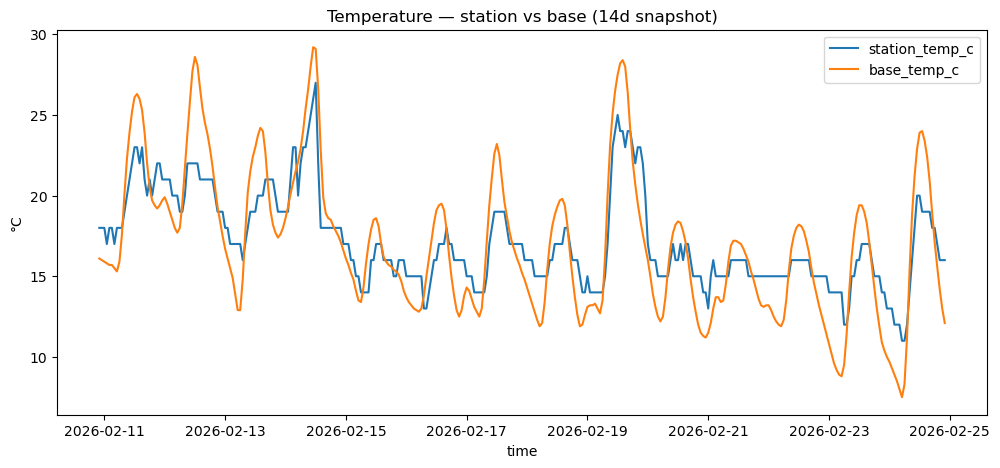

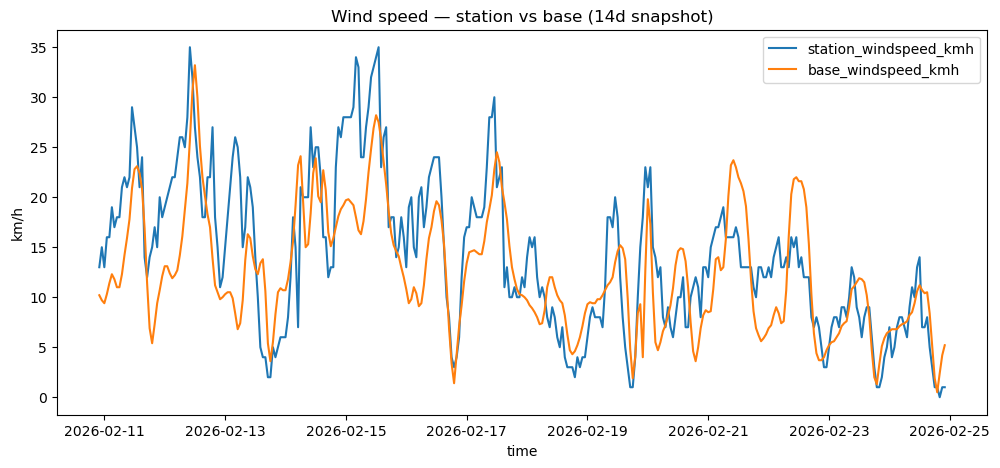

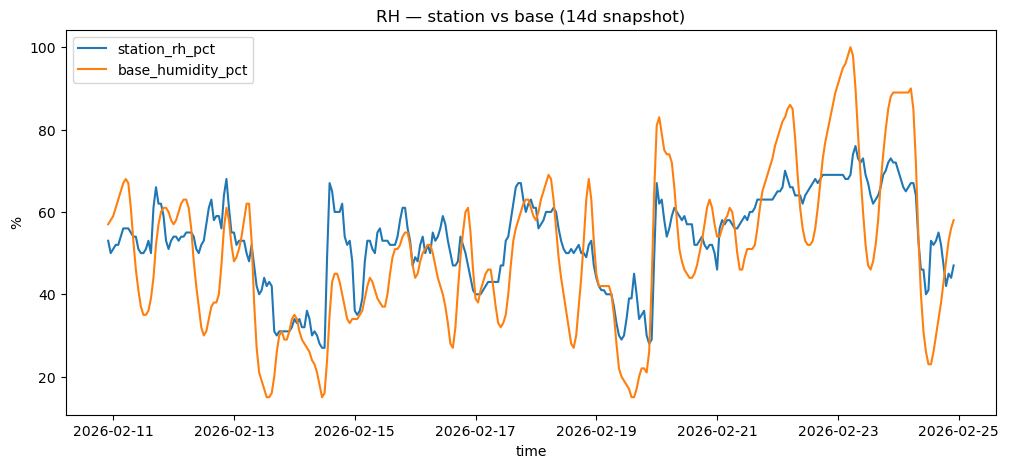

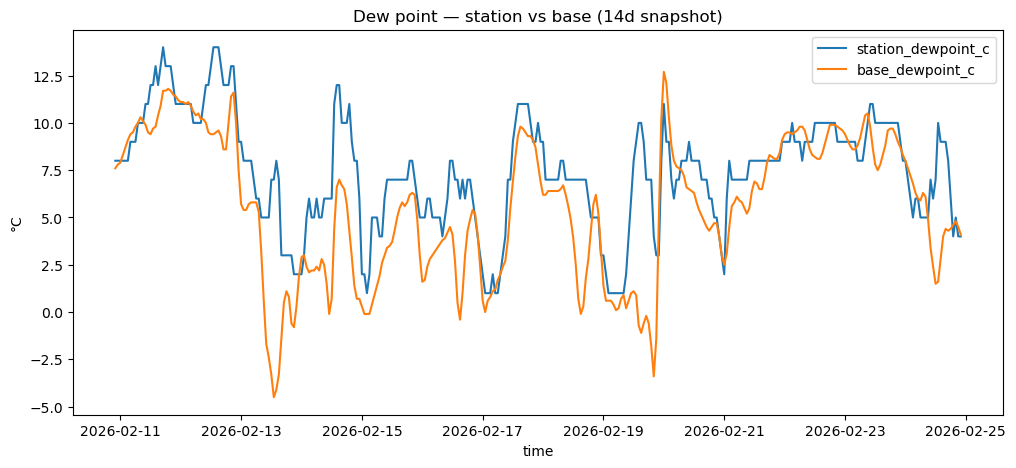

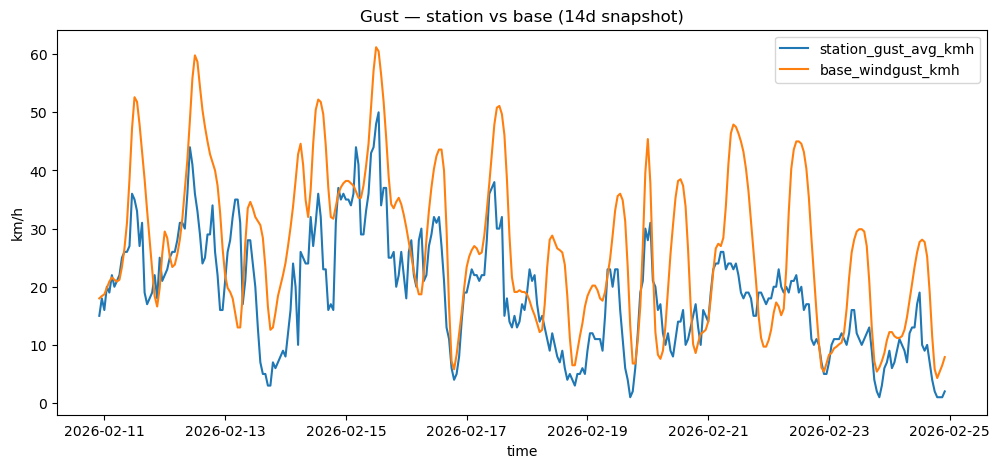

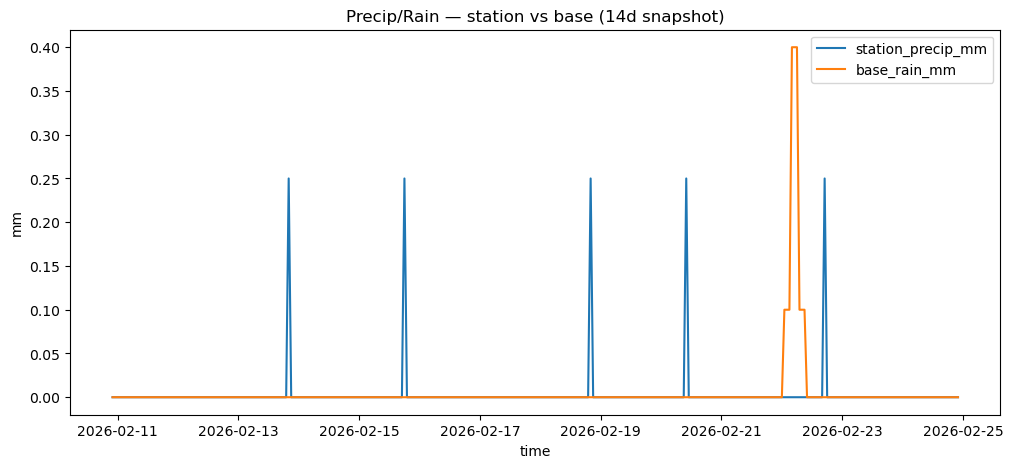

In [37]:
end = df_eval["hour_utc"].max()
start = end - pd.Timedelta(days=SAMPLE_WINDOW_DAYS)
snap = df_eval[(df_eval["hour_utc"] >= start) & (df_eval["hour_utc"] <= end)].copy()

def plot_station_vs_base(s_col, b_col, title, ylabel):
    if s_col not in snap.columns or b_col not in snap.columns:
        print("Missing columns for:", title)
        return
    plt.figure()
    plt.plot(snap["hour_utc"], pd.to_numeric(snap[s_col], errors="coerce"), label=s_col)
    plt.plot(snap["hour_utc"], pd.to_numeric(snap[b_col], errors="coerce"), label=b_col)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_station_vs_base("station_temp_c", "base_temp_c", f"Temperature — station vs base ({SAMPLE_WINDOW_DAYS}d snapshot)", "°C")
plot_station_vs_base("station_windspeed_kmh", "base_windspeed_kmh", f"Wind speed — station vs base ({SAMPLE_WINDOW_DAYS}d snapshot)", "km/h")
plot_station_vs_base("station_rh_pct", "base_humidity_pct", f"RH — station vs base ({SAMPLE_WINDOW_DAYS}d snapshot)", "%")
plot_station_vs_base("station_dewpoint_c", "base_dewpoint_c", f"Dew point — station vs base ({SAMPLE_WINDOW_DAYS}d snapshot)", "°C")

if gates.get("ENABLE_GUST") and "base_windgust_kmh" in snap.columns:
    if GUST_ERR_COL == "gust_error_avg_hourly_kmh":
        s_gust = "station_gust_avg_kmh"
    elif GUST_ERR_COL in ["gust_error_high_hourly_kmh","gust_error_high_3hmax_kmh"]:
        s_gust = "station_gust_high_kmh" if "station_gust_high_kmh" in snap.columns else "station_gust_avg_kmh"
    else:
        s_gust = "station_gust_avg_kmh"

    plot_station_vs_base(s_gust, "base_windgust_kmh", f"Gust — station vs base ({SAMPLE_WINDOW_DAYS}d snapshot)", "km/h")

if gates.get("ENABLE_RAIN"):
    if "station_precip_mm" in snap.columns:
        plt.figure()
        plt.plot(snap["hour_utc"], pd.to_numeric(snap["station_precip_mm"], errors="coerce"), label="station_precip_mm")
        if "base_rain_mm" in snap.columns:
            plt.plot(snap["hour_utc"], pd.to_numeric(snap["base_rain_mm"], errors="coerce"), label="base_rain_mm")
        elif "base_precip_mm" in snap.columns:
            plt.plot(snap["hour_utc"], pd.to_numeric(snap["base_precip_mm"], errors="coerce"), label="base_precip_mm")
        plt.title(f"Precip/Rain — station vs base ({SAMPLE_WINDOW_DAYS}d snapshot)")
        plt.xlabel("time")
        plt.ylabel("mm")
        plt.legend()
        plt.show()
else:
    print("Rain plots skipped (insufficient rain).")

<h2> 2.8: error time series and rolling drift </h2>

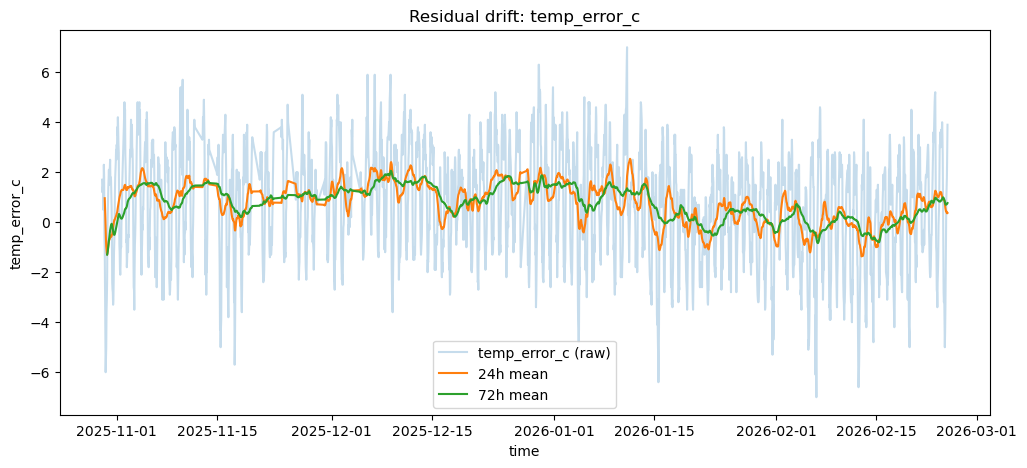

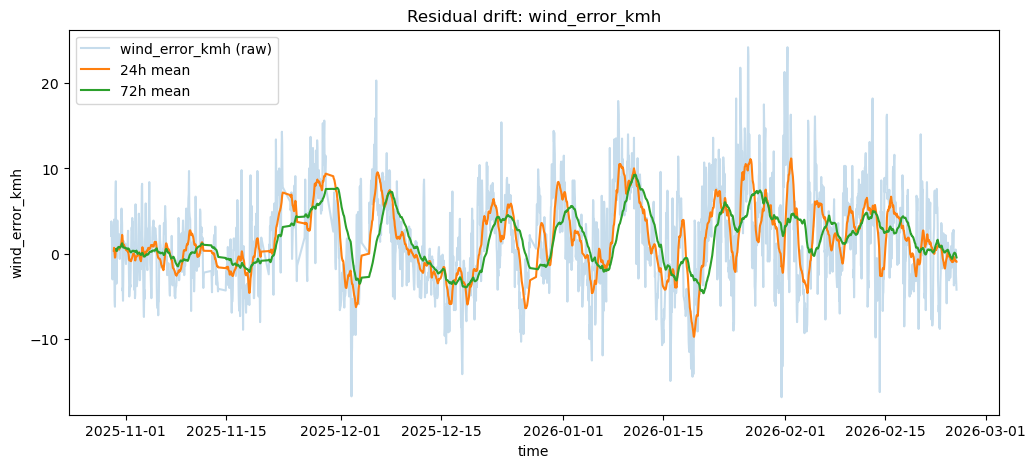

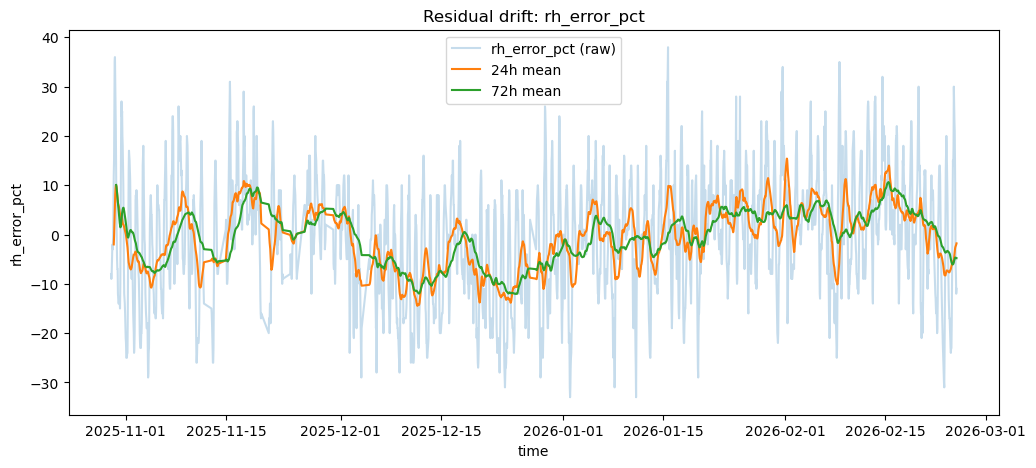

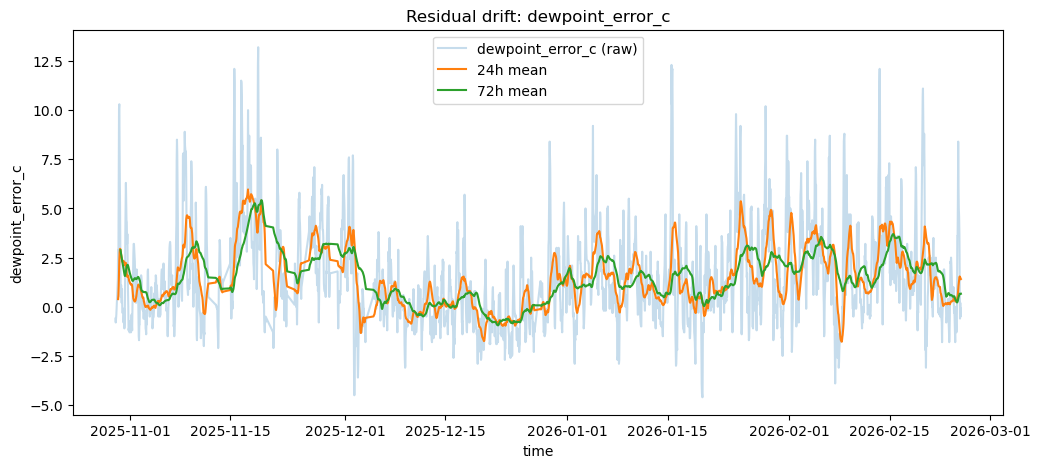

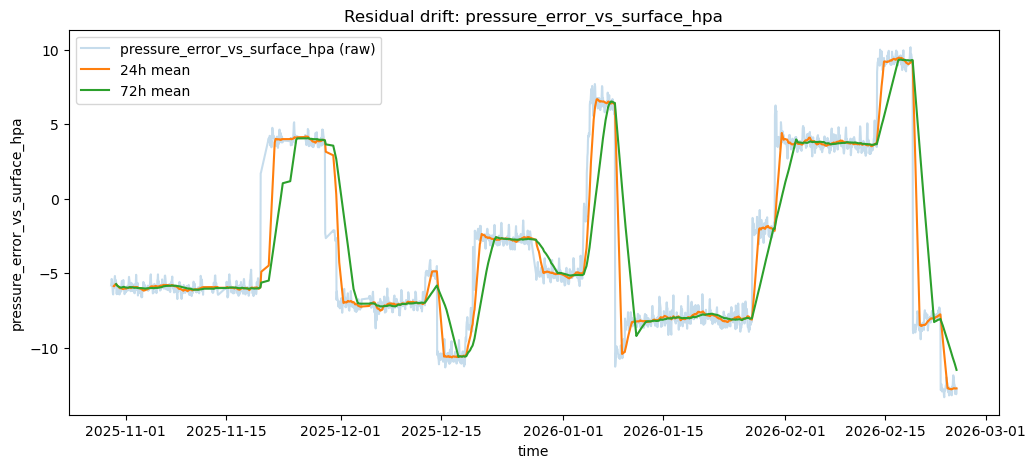

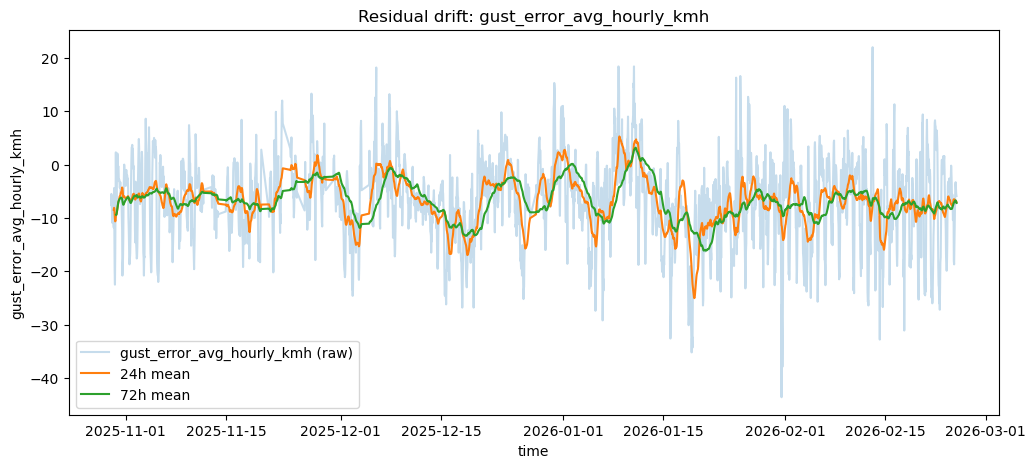

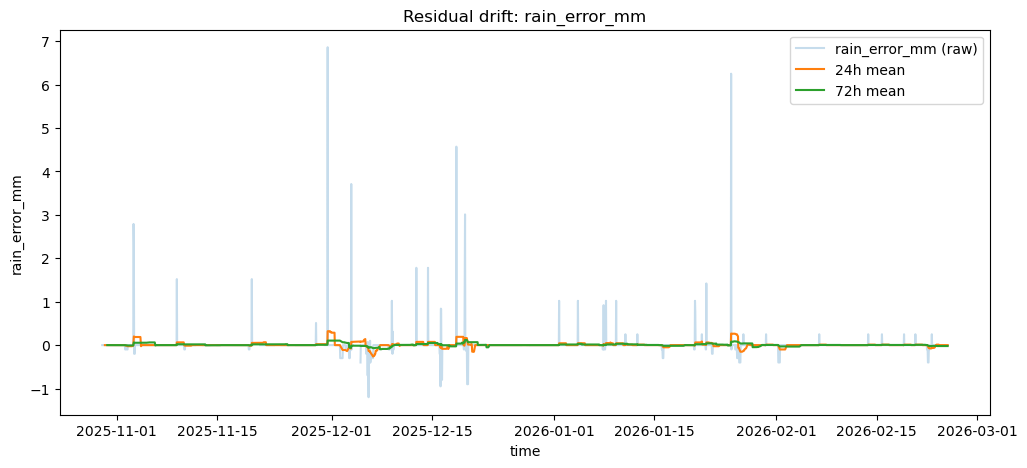

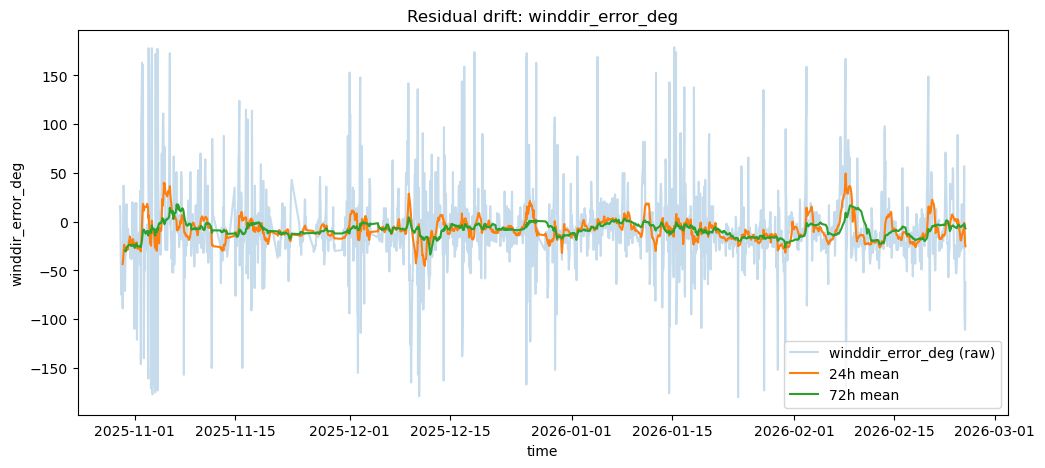

In [38]:
error_cols = [
    "temp_error_c",
    "wind_error_kmh",
    "rh_error_pct",
    "dewpoint_error_c",
]
if PRESSURE_ERR_COL:
    error_cols.append(PRESSURE_ERR_COL)
if gates.get("ENABLE_GUST") and GUST_ERR_COL:
    error_cols.append(GUST_ERR_COL)
if gates.get("ENABLE_RAIN") and "rain_error_mm" in df_eval.columns:
    error_cols.append("rain_error_mm")
if "winddir_error_deg" in df_eval.columns:
    error_cols.append("winddir_error_deg")

for col in error_cols:
    s = pd.to_numeric(df_eval[col], errors="coerce")
    if s.notna().sum() < MIN_SAMPLES_GENERAL:
        print(f"Skipping {col}: only {int(s.notna().sum())} samples")
        continue

    roll_short = s.rolling(ROLL_SHORT_H, min_periods=max(10, ROLL_SHORT_H//4)).mean()
    roll_long  = s.rolling(ROLL_LONG_H, min_periods=max(10, ROLL_LONG_H//4)).mean()

    plt.figure()
    plt.plot(df_eval["hour_utc"], s, alpha=0.25, label=f"{col} (raw)")
    plt.plot(df_eval["hour_utc"], roll_short, label=f"{ROLL_SHORT_H}h mean")
    plt.plot(df_eval["hour_utc"], roll_long, label=f"{ROLL_LONG_H}h mean")
    plt.title(f"Residual drift: {col}")
    plt.xlabel("time")
    plt.ylabel(col)
    plt.legend()
    plt.show()

<h2>2.9: error distributions </h2>

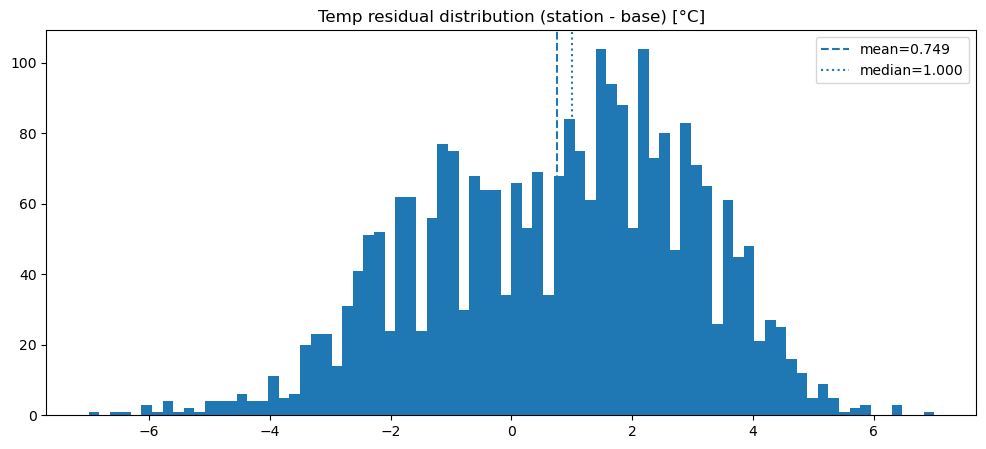

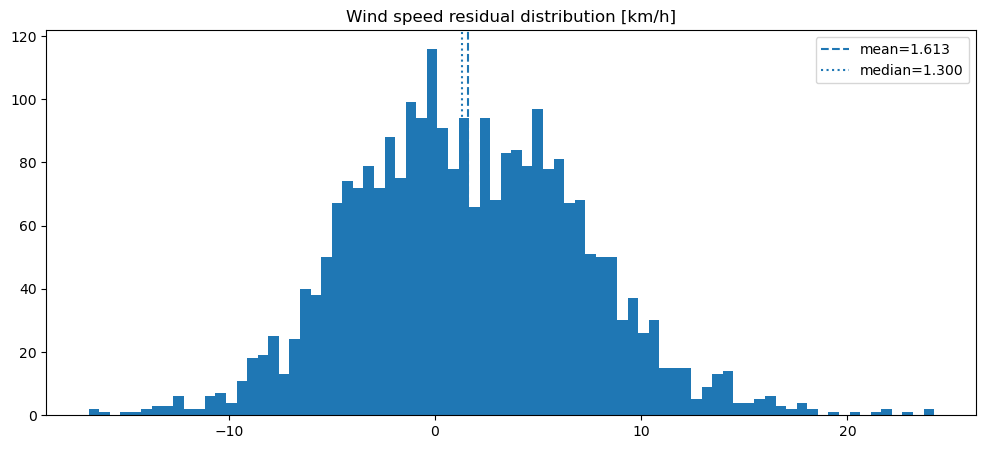

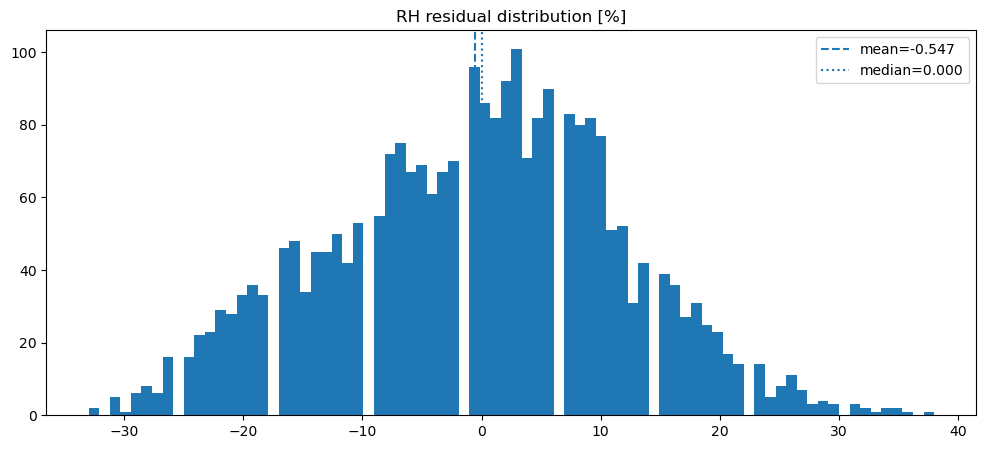

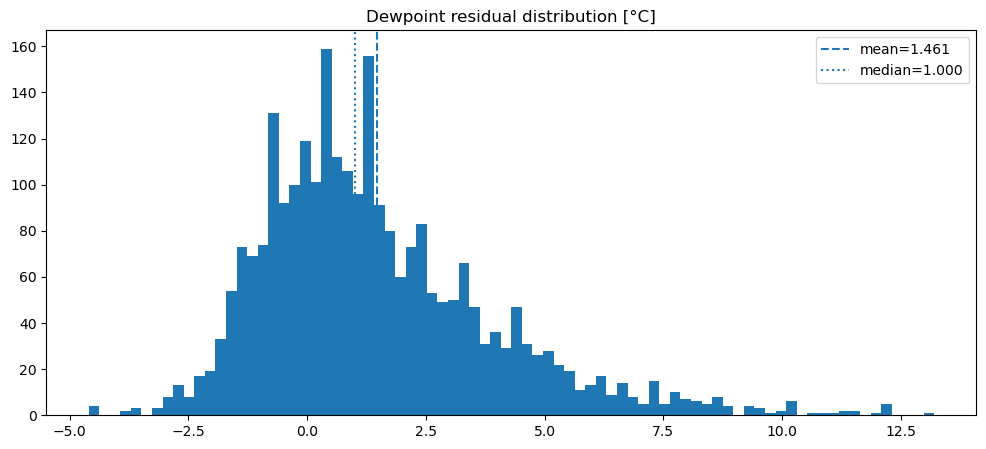

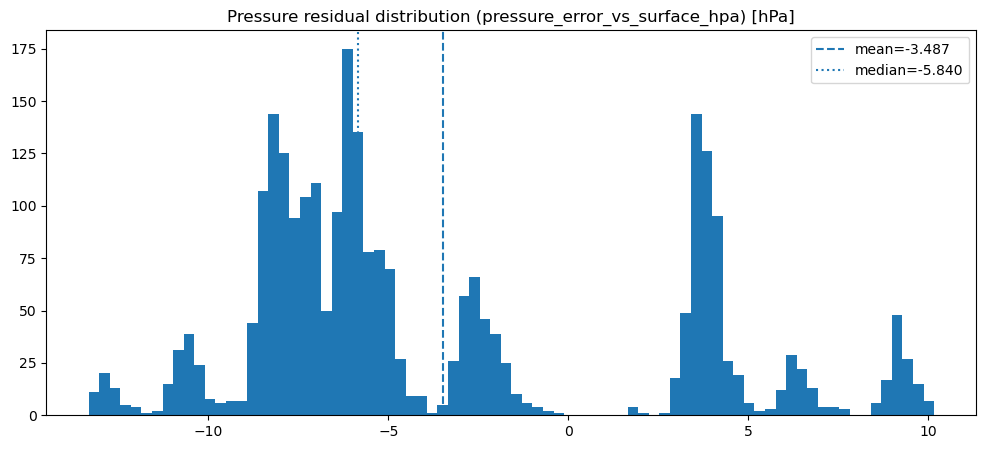

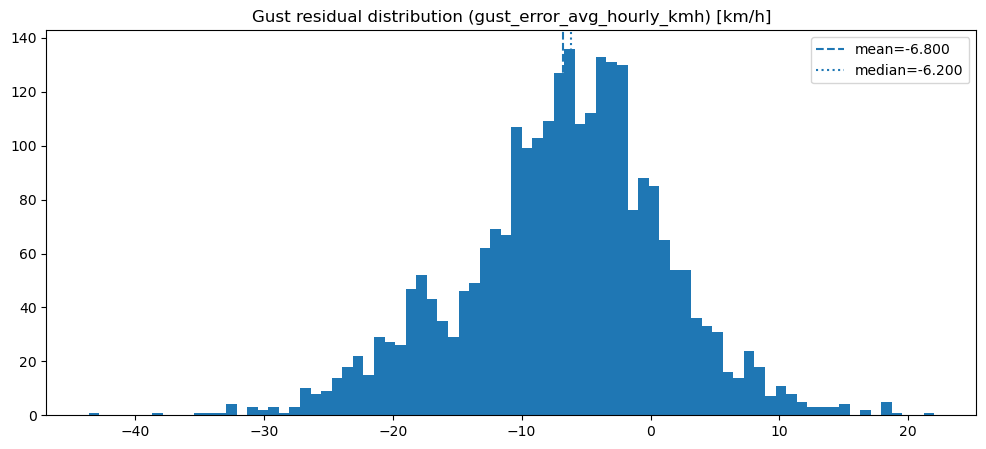

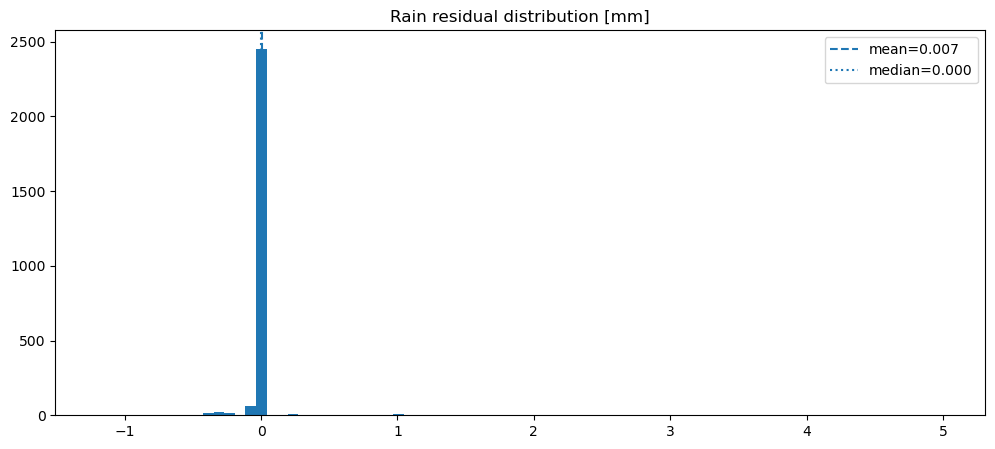

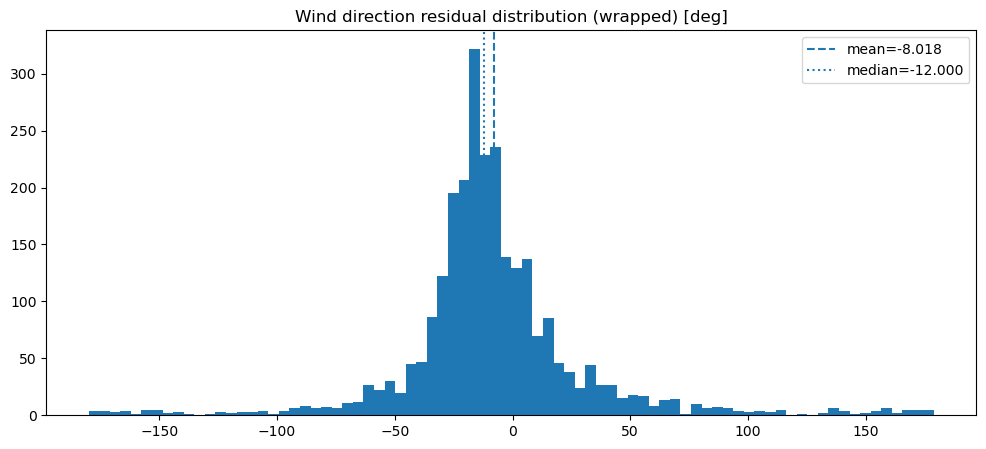

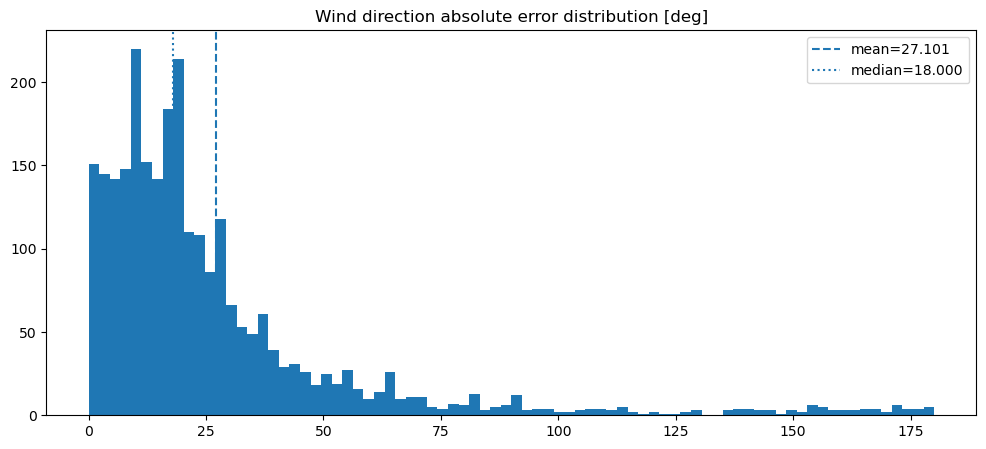

In [40]:
def hist_with_stats(series: pd.Series, title: str, bins: int = 80, clip: Optional[Tuple[float,float]] = None):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < MIN_SAMPLES_GENERAL:
        print("Skipping hist (too few samples):", title, "n=", len(s))
        return
    if clip:
        s_plot = s.clip(clip[0], clip[1])
    else:
        s_plot = s

    mean = float(s.mean())
    med = float(s.median())

    plt.figure()
    plt.hist(s_plot, bins=bins)
    plt.axvline(mean, linestyle="--", label=f"mean={mean:.3f}")
    plt.axvline(med, linestyle=":", label=f"median={med:.3f}")
    plt.title(title)
    plt.legend()
    plt.show()

hist_with_stats(df_eval["temp_error_c"], "Temp residual distribution (station - base) [°C]", clip=(-16,16))
hist_with_stats(df_eval["wind_error_kmh"], "Wind speed residual distribution [km/h]", clip=(-60,60))
if "rh_error_pct" in df_eval.columns:
    hist_with_stats(df_eval["rh_error_pct"], "RH residual distribution [%]", clip=(-80,80))
if "dewpoint_error_c" in df_eval.columns:
    hist_with_stats(df_eval["dewpoint_error_c"], "Dewpoint residual distribution [°C]", clip=(-16,16))

if PRESSURE_ERR_COL and PRESSURE_ERR_COL in df_eval.columns:
    hist_with_stats(df_eval[PRESSURE_ERR_COL], f"Pressure residual distribution ({PRESSURE_ERR_COL}) [hPa]", clip=(-40,40))

if gates.get("ENABLE_GUST") and GUST_ERR_COL in df_eval.columns:
    hist_with_stats(df_eval[GUST_ERR_COL], f"Gust residual distribution ({GUST_ERR_COL}) [km/h]", clip=(-100,100))

if gates.get("ENABLE_RAIN") and "rain_error_mm" in df_eval.columns:
    hist_with_stats(df_eval["rain_error_mm"], "Rain residual distribution [mm]", bins=80, clip=(-5,5))
else:
    print("Rain residual histogram skipped (insufficient rain).")

if "winddir_error_deg" in df_eval.columns:
    hist_with_stats(df_eval["winddir_error_deg"], "Wind direction residual distribution (wrapped) [deg]", bins=80, clip=(-180,180))
    abs_ang = pd.to_numeric(df_eval["winddir_error_deg"], errors="coerce").abs()
    hist_with_stats(abs_ang, "Wind direction absolute error distribution [deg]", bins=80, clip=(0,180))

<h2>2.10: hour of day profiles </h2>

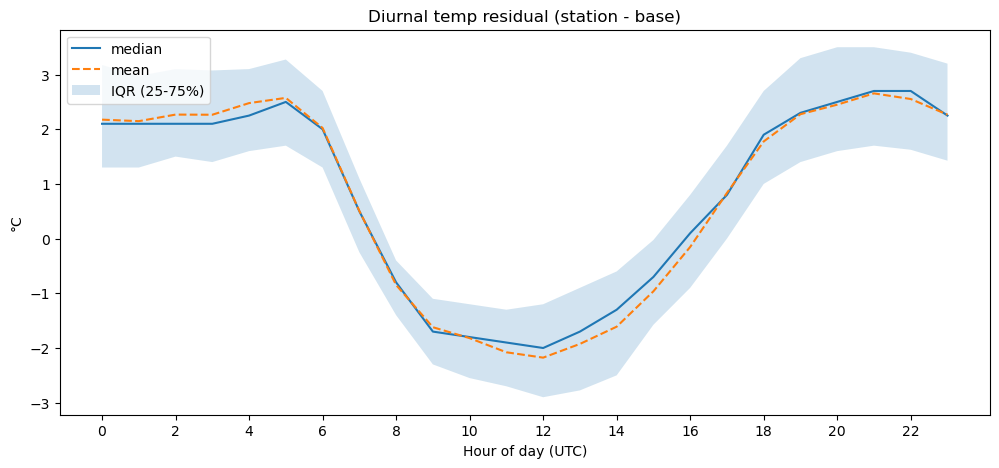

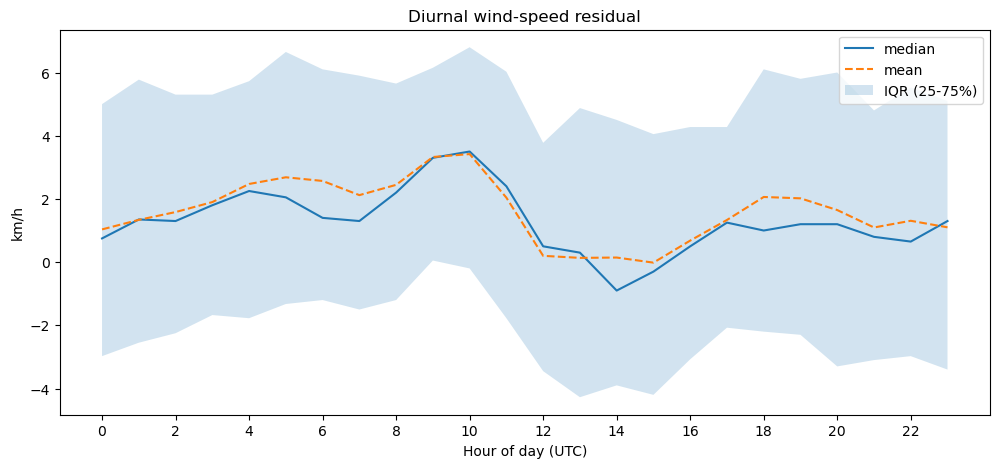

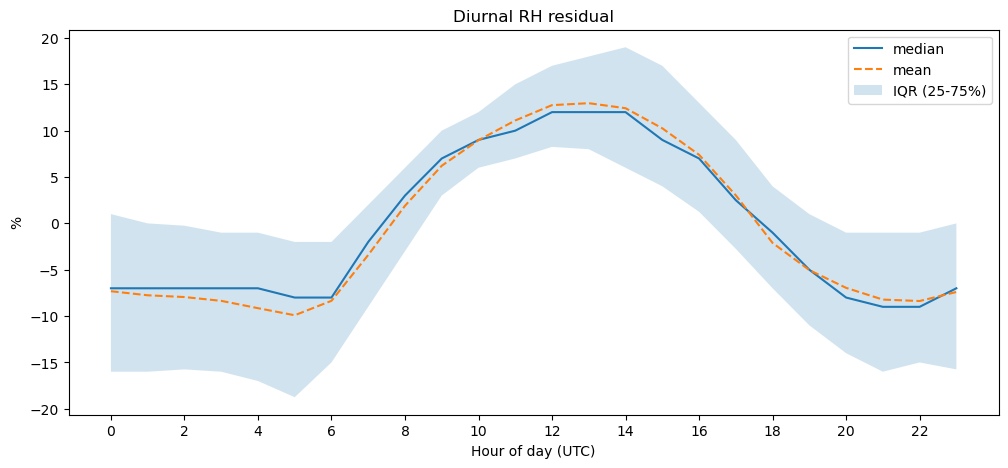

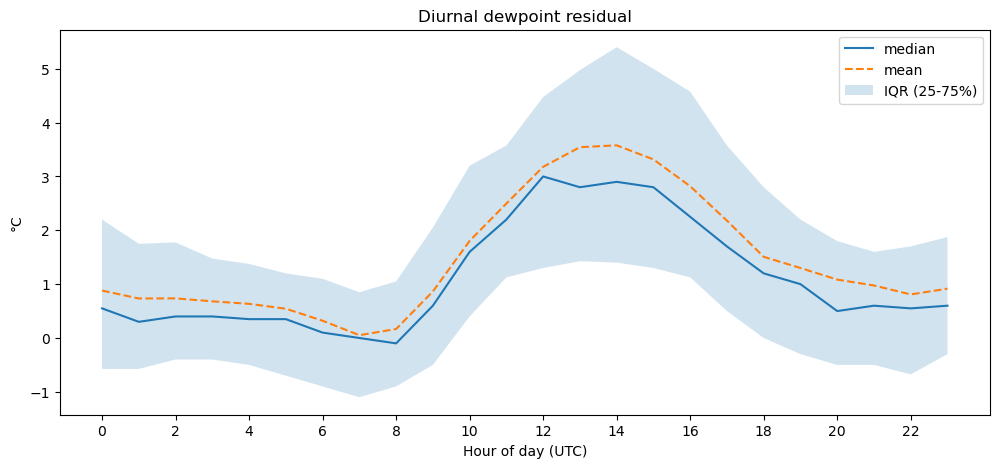

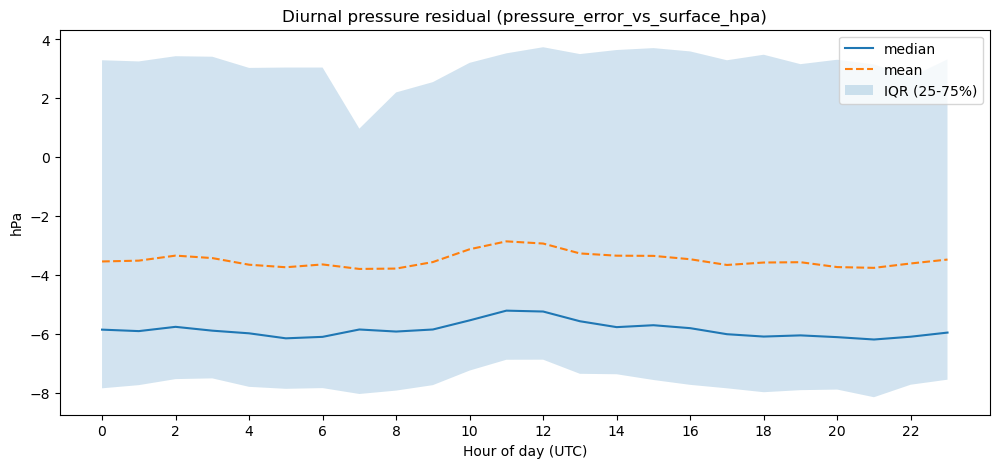

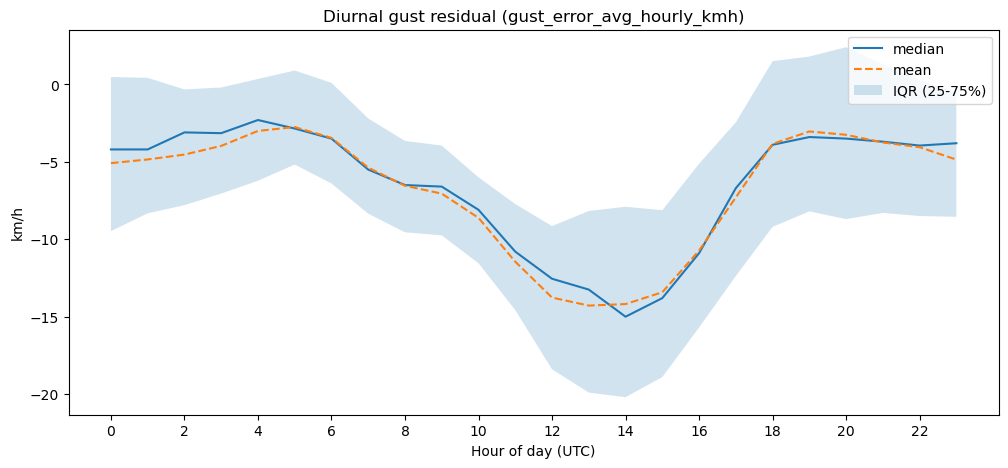

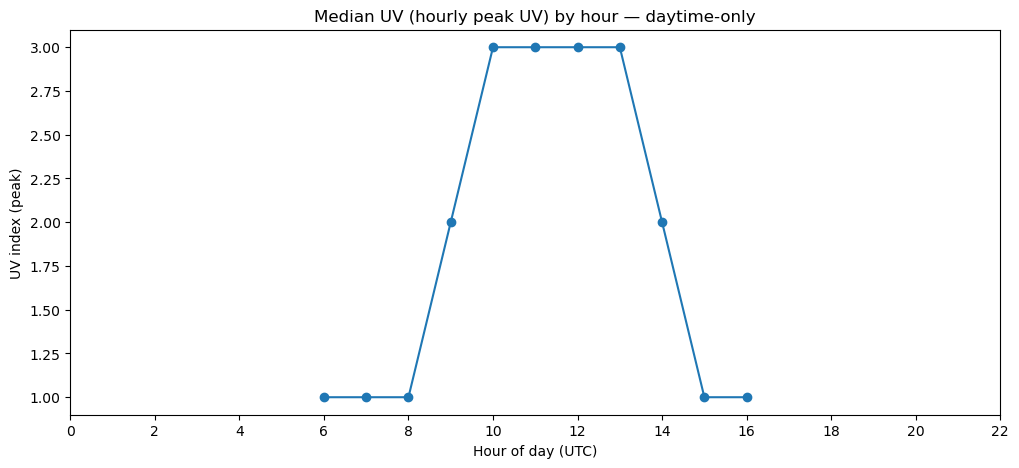

In [41]:
def diurnal_plot(col: str, title: str, ylabel: str, require_n: int = MIN_SAMPLES_GENERAL):
    if col not in df_eval.columns:
        print("Missing:", col)
        return
    s = pd.to_numeric(df_eval[col], errors="coerce")
    if s.notna().sum() < require_n:
        print("Skipping diurnal (too few):", col, int(s.notna().sum()))
        return

    g = df_eval.assign(val=s).dropna(subset=["val"]).groupby("hour")["val"]
    q25 = g.quantile(0.25)
    q50 = g.quantile(0.50)
    q75 = g.quantile(0.75)
    mean = g.mean()

    plt.figure()
    plt.plot(q50.index, q50.values, label="median")
    plt.plot(mean.index, mean.values, linestyle="--", label="mean")
    plt.fill_between(q25.index, q25.values, q75.values, alpha=0.2, label="IQR (25-75%)")
    plt.title(title)
    plt.xlabel("Hour of day (UTC)")
    plt.ylabel(ylabel)
    plt.xticks(range(0,24,2))
    plt.legend()
    plt.show()

diurnal_plot("temp_error_c", "Diurnal temp residual (station - base)", "°C")
diurnal_plot("wind_error_kmh", "Diurnal wind-speed residual", "km/h")
if "rh_error_pct" in df_eval.columns:
    diurnal_plot("rh_error_pct", "Diurnal RH residual", "%")
if "dewpoint_error_c" in df_eval.columns:
    diurnal_plot("dewpoint_error_c", "Diurnal dewpoint residual", "°C")

if PRESSURE_ERR_COL:
    diurnal_plot(PRESSURE_ERR_COL, f"Diurnal pressure residual ({PRESSURE_ERR_COL})", "hPa")

if gates.get("ENABLE_GUST") and GUST_ERR_COL:
    diurnal_plot(GUST_ERR_COL, f"Diurnal gust residual ({GUST_ERR_COL})", "km/h")

if gates.get("ENABLE_UV") and "uv_target" in df_eval.columns:
    day = df_eval[df_eval["is_day_flag"] == 1].copy()
    day["uv_target_num"] = pd.to_numeric(day["uv_target"], errors="coerce")
    g = day.dropna(subset=["uv_target_num"]).groupby("hour")["uv_target_num"].median()

    plt.figure()
    plt.plot(g.index, g.values, marker="o")
    plt.title("Median UV (hourly peak UV) by hour — daytime-only")
    plt.xlabel("Hour of day (UTC)")
    plt.ylabel("UV index (peak)")
    plt.xticks(range(0,24,2))
    plt.show()
else:
    print("UV diurnal skipped (insufficient daytime UV samples).")

<h2>2.11: day/night, wet/dry </h2>

In [42]:
def mae(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce")
    return float(s.abs().mean())

def stratified_mae(col: str) -> pd.DataFrame:
    s = pd.to_numeric(df_eval[col], errors="coerce")
    d = df_eval.copy()
    d["val"] = s
    d = d.dropna(subset=["val"])

    out = []
    for day_flag, day_name in [(0, "night"), (1, "day")]:
        sub = d[d["is_day_flag"] == day_flag]
        if len(sub) >= 50:
            out.append({"target": col, "stratum": day_name, "n": len(sub), "mae": mae(sub["val"])})
        else:
            out.append({"target": col, "stratum": day_name, "n": len(sub), "mae": np.nan})

    if gates.get("ENABLE_RAIN") and "is_wet" in d.columns and d["is_wet"].notna().any():
        for wet_flag, wet_name in [(0, "dry"), (1, "wet")]:
            sub = d[d["is_wet"] == wet_flag]
            if len(sub) >= 50:
                out.append({"target": col, "stratum": wet_name, "n": len(sub), "mae": mae(sub["val"])})
            else:
                out.append({"target": col, "stratum": wet_name, "n": len(sub), "mae": np.nan})

        for day_flag, day_name in [(0, "night"), (1, "day")]:
            for wet_flag, wet_name in [(0, "dry"), (1, "wet")]:
                sub = d[(d["is_day_flag"] == day_flag) & (d["is_wet"] == wet_flag)]
                if len(sub) >= 50:
                    out.append({"target": col, "stratum": f"{day_name}+{wet_name}", "n": len(sub), "mae": mae(sub["val"])})

    return pd.DataFrame(out)

cols_for_strata = ["temp_error_c","wind_error_kmh"]
if "rh_error_pct" in df_eval.columns:
    cols_for_strata.append("rh_error_pct")
if "dewpoint_error_c" in df_eval.columns:
    cols_for_strata.append("dewpoint_error_c")
if PRESSURE_ERR_COL:
    cols_for_strata.append(PRESSURE_ERR_COL)
if gates.get("ENABLE_GUST") and GUST_ERR_COL:
    cols_for_strata.append(GUST_ERR_COL)

all_strata = pd.concat([stratified_mae(c) for c in cols_for_strata], ignore_index=True)
display(all_strata)

,target,stratum,n,mae
0,temp_error_c,night,1485,2.255488
1,temp_error_c,day,1155,1.615238
2,temp_error_c,dry,2590,1.979421
3,temp_error_c,wet,50,1.766000
4,temp_error_c,night+dry,1458,2.258985
5,temp_error_c,day+dry,1132,1.619346
6,wind_error_kmh,night,1485,4.785185
7,wind_error_kmh,day,1155,4.412641
8,wind_error_kmh,dry,2590,4.610656
9,wind_error_kmh,wet,50,5.220000


<h2>2.12: regime scatter plots </h2>

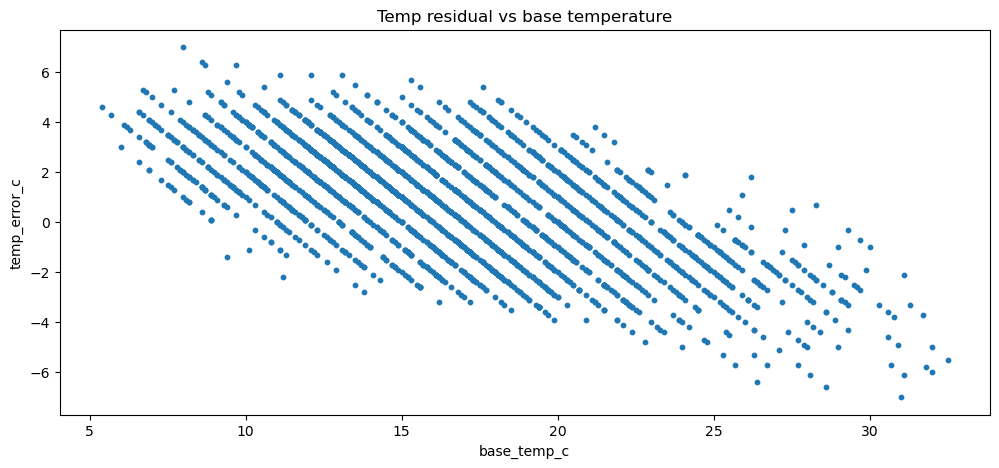

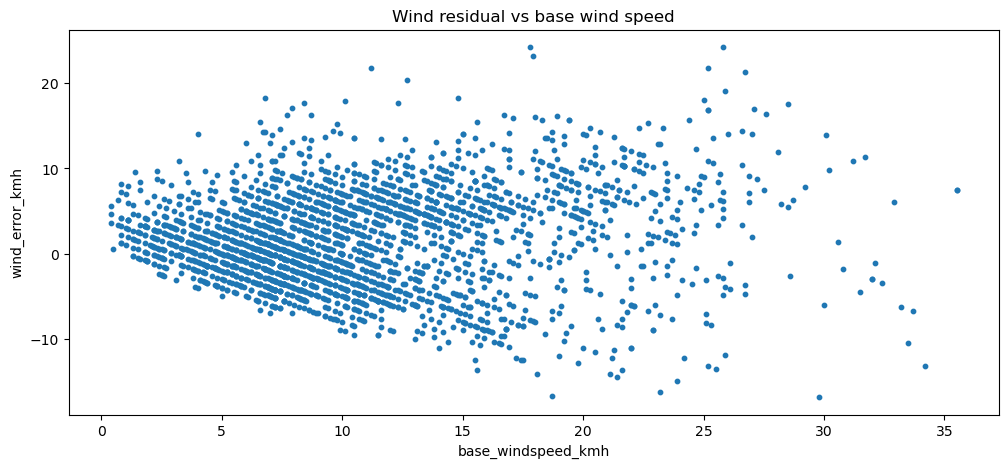

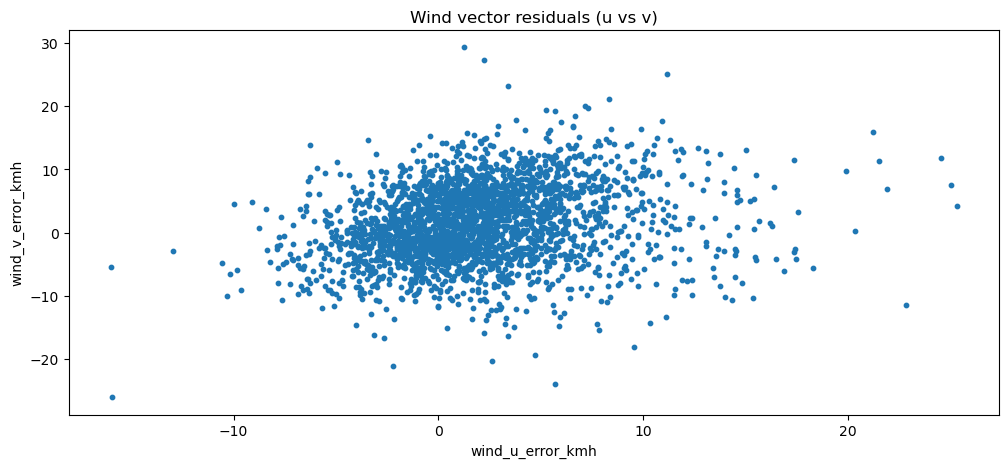

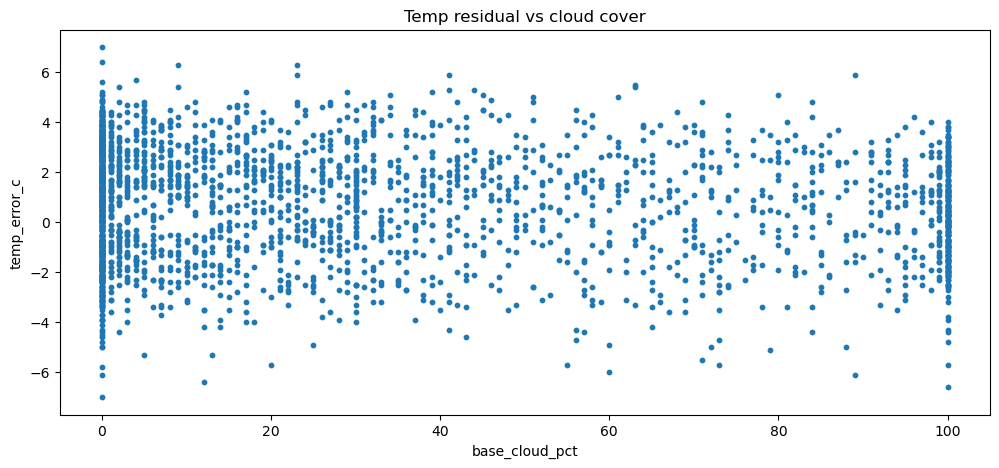

In [43]:
def scatter(x_col, y_col, title, xlab=None, ylab=None, sample=4000):
    if x_col not in df_eval.columns or y_col not in df_eval.columns:
        print("Missing for scatter:", x_col, y_col)
        return
    x = pd.to_numeric(df_eval[x_col], errors="coerce")
    y = pd.to_numeric(df_eval[y_col], errors="coerce")
    d = df_eval[["hour_utc"]].copy()
    d["x"] = x
    d["y"] = y
    d = d.dropna()

    if len(d) > sample:
        d = d.sample(sample, random_state=0)

    plt.figure()
    plt.scatter(d["x"], d["y"], s=10)
    plt.title(title)
    plt.xlabel(xlab or x_col)
    plt.ylabel(ylab or y_col)
    plt.show()

scatter("base_temp_c", "temp_error_c", "Temp residual vs base temperature", "base_temp_c", "temp_error_c")
scatter("base_windspeed_kmh", "wind_error_kmh", "Wind residual vs base wind speed", "base_windspeed_kmh", "wind_error_kmh")

if "wind_u_error_kmh" in df_eval.columns and "wind_v_error_kmh" in df_eval.columns:
    scatter("wind_u_error_kmh", "wind_v_error_kmh", "Wind vector residuals (u vs v)", "wind_u_error_kmh", "wind_v_error_kmh")

if "base_cloud_pct" in df_eval.columns:
    scatter("base_cloud_pct", "temp_error_c", "Temp residual vs cloud cover", "base_cloud_pct", "temp_error_c")

<h2> 2.13: correlation scan </h2>

In [44]:
feature_cols = [c for c in df_eval.columns if c.startswith("base_")]
feature_cols += ["hour","dow","doy","is_day_flag"]

feature_cols = [c for c in feature_cols if not c.startswith("station_") and ("error" not in c)]

target_cols = ["temp_error_c","wind_error_kmh"]
if "rh_error_pct" in df_eval.columns:
    target_cols.append("rh_error_pct")
if "dewpoint_error_c" in df_eval.columns:
    target_cols.append("dewpoint_error_c")
if PRESSURE_ERR_COL:
    target_cols.append(PRESSURE_ERR_COL)
if gates.get("ENABLE_GUST") and GUST_ERR_COL:
    target_cols.append(GUST_ERR_COL)

def top_corrs(target: str, k: int = 15) -> pd.DataFrame:
    if target not in df_eval.columns:
        return pd.DataFrame()
    y = pd.to_numeric(df_eval[target], errors="coerce")
    rows = []
    for f in feature_cols:
        x = pd.to_numeric(df_eval[f], errors="coerce")
        mask = x.notna() & y.notna()
        if mask.sum() < MIN_SAMPLES_GENERAL:
            continue
        corr = x[mask].corr(y[mask])
        rows.append((f, corr, int(mask.sum())))
    out = pd.DataFrame(rows, columns=["feature","corr","n"]).dropna()
    out["abs_corr"] = out["corr"].abs()
    return out.sort_values("abs_corr", ascending=False).head(k)

for t in target_cols:
    print("\nTop correlations for:", t)
    display(top_corrs(t, k=20))


Top correlations for: temp_error_c


,feature,corr,n,abs_corr
16,base_diffuse_wm2,-0.804077,2640,0.804077
14,base_shortwave_wm2,-0.783641,2640,0.783641
17,base_sunshine_sec,-0.781042,2640,0.781042
15,base_direct_wm2,-0.738311,2640,0.738311
24,is_day_flag,-0.737551,2640,0.737551
0,base_temp_c,-0.645733,2640,0.645733
1,base_humidity_pct,0.567763,2640,0.567763
7,base_windgust_kmh,-0.553777,2640,0.553777
5,base_windspeed_kmh,-0.425340,2640,0.425340
19,base_u_kmh,-0.315607,2640,0.315607



Top correlations for: wind_error_kmh


,feature,corr,n,abs_corr
19,base_u_kmh,0.551320,2640,0.551320
6,base_winddir_deg,0.378883,2640,0.378883
0,base_temp_c,-0.195198,2640,0.195198
13,base_cloud_high_pct,-0.194800,2640,0.194800
20,base_v_kmh,-0.160486,2640,0.160486
7,base_windgust_kmh,0.157267,2640,0.157267
2,base_dewpoint_c,-0.131353,2640,0.131353
5,base_windspeed_kmh,0.118538,2640,0.118538
23,doy,-0.111202,2640,0.111202
12,base_cloud_mid_pct,-0.097898,2640,0.097898



Top correlations for: rh_error_pct


...

,feature,corr,n,abs_corr
1,base_humidity_pct,-0.742698,2640,0.742698
2,base_dewpoint_c,-0.539028,2640,0.539028
0,base_temp_c,0.506761,2640,0.506761
15,base_direct_wm2,0.353531,2640,0.353531
14,base_shortwave_wm2,0.343241,2640,0.343241
16,base_diffuse_wm2,0.292460,2640,0.292460
7,base_windgust_kmh,0.288014,2640,0.288014
17,base_sunshine_sec,0.271871,2640,0.271871
19,base_u_kmh,0.264093,2640,0.264093
3,base_pressure_msl_hpa,-0.253953,2640,0.253953



Top correlations for: pressure_error_vs_surface_hpa


,feature,corr,n,abs_corr
3,base_pressure_msl_hpa,-0.413381,2640,0.413381
4,base_surface_pressure_hpa,-0.413332,2640,0.413332
19,base_u_kmh,0.306278,2640,0.306278
1,base_humidity_pct,-0.255660,2640,0.255660
23,doy,-0.234194,2640,0.234194
5,base_windspeed_kmh,0.216526,2640,0.216526
7,base_windgust_kmh,0.209176,2640,0.209176
2,base_dewpoint_c,-0.195093,2640,0.195093
6,base_winddir_deg,0.190899,2640,0.190899
11,base_cloud_low_pct,-0.140223,2640,0.140223



Top correlations for: gust_error_avg_hourly_kmh


,feature,corr,n,abs_corr
7,base_windgust_kmh,-0.472736,2640,0.472736
0,base_temp_c,-0.454219,2640,0.454219
16,base_diffuse_wm2,-0.442398,2640,0.442398
14,base_shortwave_wm2,-0.408306,2640,0.408306
17,base_sunshine_sec,-0.394903,2640,0.394903
5,base_windspeed_kmh,-0.393828,2640,0.393828
15,base_direct_wm2,-0.372856,2640,0.372856
24,is_day_flag,-0.367899,2640,0.367899
1,base_humidity_pct,0.347713,2640,0.347713
3,base_pressure_msl_hpa,0.201726,2640,0.201726


<h2>2.14: save EDA </h2>

In [45]:
trainability_path = OUT_DIR / f"trainability_{STATION_ID}.csv"
trainability.to_csv(trainability_path, index=False)

strata_path = OUT_DIR / f"stratified_mae_{STATION_ID}.csv"
all_strata.to_csv(strata_path, index=False)

print("Saved:", trainability_path)
print("Saved:", strata_path)

print("Gates JSON:", OUT_DIR / f"gates_{STATION_ID}.json")

Saved: eda_v2_outputs_part2\trainability_ITRIPO33.csv
Saved: eda_v2_outputs_part2\stratified_mae_ITRIPO33.csv
Gates JSON: eda_v2_outputs_part2\gates_ITRIPO33.json
